# PHAS0056 MINI PROJECT: IDENTIFICATION OF JETS AT THE LHC

## table of contents

1. [Introduction](#introduction)
2. [Data Preprocessing](#process)
3. [Task 1: Jet Image Classifyer](#image)
4. [Task 2: Jet Image + Features](#features)
5. [Extension 1: ECAL & HCAL Images ](#feat)
6. [Extension 2: Features Only](#CAL)
7. [Extension 3: Combined Image and Feature Classifier](#All)
8. [Performance Comparison](#which)
9. [Which particle classes are easisest to distinguish?](#sep)
10. [Conclusion](#sep)


## 1. Introduction


This notebook introduces the use of machine learning techniques for the classification of particle jets produced in proton–proton collisions at the Large Hadron Collider; because modern collider experiments generate an enormous amount of data, automated analysis methods are essential for effectively identifying the physical processes that produced each jet. In this context machine learning algorithms provide powerful tools for building tagging models capable of distinguishing between different jet types, helping physicists analyze collision events more effectively and test theoretical predictions in high-energy physics. 

In [303]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
import pandas as pd
import h5py
import urllib.request
import os

mpl.rcParams['figure.max_open_warning'] = 0
plt.rcParams['axes.labelsize'] = 18
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams.update({'font.size': 16, 'font.family': 'serif', 'mathtext.fontset': 'stix'})

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.layers import concatenate, Activation, Add, GlobalAveragePooling2D, InputLayer
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize, StandardScaler
scaler = StandardScaler()
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

from numpy import interp
from itertools import cycle
import seaborn as sns

## 2. Data Preprocessing

We will be using a publicly available dataset called HLS4ML, representing LHC proton-proton collision simulations, [available on Zenodo](https://zenodo.org/records/3602254). Each h5 file consists of 10,000 images that represent how the jet looks inside the detector, as well as 10,000 Electromagnetic and Hadronic Calorimeter (ECAL and HCAL) images, and several scalar features for each image. \
Overall there are 5 types of particles initiating the jets: **gluons, quarks, W, Z and top**. 

### 2.1 Functions

 Here I defined all the functions which support data handling and model evaluation throughout the project:

 - `get_data()` — loads and preprocesses jet image data from `.h5` files.

 - `loss_acc()` — plots training/validation accuracy and loss.

 - `ROC()` — plots ROC curves and calculates AUC for each particle type.

 - `confusion_matrix()` — plots confusion matrix and calculates per-class accuracy.



In [ ]:
def get_data(filename):

    ''' Function to extract data from h5 file 

    input: 
    filename: string, file path
    
    returns:
    normalised arrays of gluon, quark, w, z and top 100x100 jet images '''
    
    #Opening the h5 file

    #The name of the file we are looking at
    file = filename
    
    #Opening the file with h5  
    df = h5py.File(file,'r')
    
    #Getting labels for each column
    labels = [label.decode('utf-8') for label in df['jetFeatureNames'][:] ]
    
    #Looking at the jet image column
    pJet = pd.DataFrame(np.array(df['jets']), columns = labels)
    
    #Only getting image data for each image when the particle type column is 1
    data_g = pJet.drop(pJet[pJet.j_g ==0].index)
    data_q = pJet.drop(pJet[pJet.j_q ==0].index)
    data_w = pJet.drop(pJet[pJet.j_w ==0].index)
    data_z = pJet.drop(pJet[pJet.j_z ==0].index)
    data_t = pJet.drop(pJet[pJet.j_t ==0].index)
    
    #Turn the image into a numpy array
    gluon_img = df['jetImage'][:] * np.array(pJet['j_g'])[:, None, None]
    quark_img = df['jetImage'][:] * np.array(pJet['j_q'])[:, None, None]
    w_img = df['jetImage'][:] * np.array(pJet['j_w'])[:, None, None]
    z_img = df['jetImage'][:] * np.array(pJet['j_z'])[:, None, None]
    top_img = df['jetImage'][:] * np.array(pJet['j_t'])[:, None, None]
    
    #Remove blank images (where the sum of all pixels is 0)
    gluon_img = gluon_img[np.where(np.sum(gluon_img, axis=(1, 2)) != 0)[0]]
    quark_img = quark_img[np.where(np.sum(quark_img, axis=(1, 2)) != 0)[0]]
    w_img = w_img[np.where(np.sum(w_img, axis=(1, 2)) != 0)[0]]
    z_img = z_img[np.where(np.sum(z_img, axis=(1, 2)) != 0)[0]]
    top_img = top_img[np.where(np.sum(top_img, axis=(1, 2)) != 0)[0]]
    
    #Normalise all images
    for i in range(len(gluon_img)):
        gluon_img[i] = gluon_img[i] / np.max(gluon_img)
    for i in range(len(quark_img)):
        quark_img[i] = quark_img[i] / np.max(quark_img)
    for i in range(len(w_img)):
        w_img[i] = w_img[i] / np.max(w_img)
    for i in range(len(z_img)):
        z_img[i] = z_img[i] / np.max(z_img)
    for i in range(len(top_img)):
        top_img[i] = top_img[i] / np.max(top_img)
    
    return gluon_img, quark_img, w_img, z_img, top_img


def loss_acc(his, name):

    ''' Function to plot the validationa and training loss & accuracy of a model

    inputs:
    his - the history data returned after using model.fit
    name - string for the name of the file plots are saved to '''
    
    n = np.size(his.history['accuracy']) #Plotting points
    
    fig, axs = plt.subplots(1, 2, figsize = (12, 6))
    
    #Accuracy
    axs[0].plot(np.arange(1, n + 1, 1), his.history['accuracy'], color = 'crimson', label = 'Training')
    axs[0].plot(np.arange(1, n + 1, 1), his.history['val_accuracy'], color='turquoise', label='Validation')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].legend(loc = 'best', frameon = False)
    plt.savefig(f'accuracy {name}.pdf')
    
    #Loss
    axs[1].plot(np.arange(1, n + 1, 1), his.history['loss'], color = 'crimson', label = 'Training')
    axs[1].plot(np.arange(1, n + 1, 1), his.history['val_loss'], color='turquoise', label = 'Validation')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    plt.savefig(f'loss {name}.pdf')
  
    print(f"The final accuracy was {his.history['accuracy'][-1]:.4f} and the final loss was {his.history['loss'][-1]:.4f}")
    
def ROC(prob, name):

    ''' Function to plot the ROC curve  and also return the TRP & FPR for each particle type
    inputs:
    prob - array or probabilities of each image being classified as each particle type, from using model.predict on the testing images
    name - string for the name of the file plots are saved to '''
    
    #Initialise array for FPR & TPR
    roc_data = []
    
    plt.figure()
    plt.plot([0, 1], [0, 1], '--', color = 'black') #The y=x line
    
    for i, particle in enumerate(particle_types):
        FPR, TPR, thresholds = roc_curve(labels_test_binarised[:, i], prob[:, i])
        roc_auc = auc(FPR, TPR) 
        plt.plot(FPR, TPR, label=f'{particle} (AUC = {roc_auc:.3f})')
        
        roc_data.append({
            'particle': particle,
            'FPR': FPR,
            'TPR': TPR,
            'AUC': roc_auc
        })
    
    plt.xlim(0, 1)
    plt.ylim(0, 1.1)
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.title(f'ROC ({name})')
    plt.legend(loc = 'best', frameon = False)
    plt.savefig(f'ROC_{name}.pdf', bbox_inches='tight')
    
    return roc_data
    
    
def confusion_matrix(prob, name):
    
    ''' Function to plot the confusion matrix for each model
    inputs:
    prob - array or probabilities of each image being classified as each particle type, from using model.predict on the testing images
    name -  string for the name of the file plots are saved to
    returns:
    predicted_labels - array of what particle the model thinks each image belongs to, used for F1 score
    class_accuracies - array of length 5, accuracy for each particle'''
    
    #For each image, what is the most likely particle predicted by the model?
    predicted_labels = np.argmax(prob, axis=1) 

    #Actual image recognised using the test labels
    cm = confusion_matrix(labels_test, predicted_labels) 

    cm_normalised = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    #Main diagonals of the confusion matrix
    class_accuracies = cm.diagonal() / cm.sum(axis=1) 

    for i, accuracy in enumerate(class_accuracies):
        print(f"Accuracy for {particle_types[i]}: {accuracy:.2%}")
        
    plt.figure(figsize = (8, 6))
    ax = sns.heatmap(cm_normalised, annot = True, fmt= ".2%" , cmap = 'BuPu', xticklabels = particle_types, 
            yticklabels = particle_types)
    ax.xaxis.tick_bottom()
    ax.xaxis.set_label_position('bottom')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.savefig(f'confusion {name}.pdf', dpi = 1000)
    plt.show()
    
    return predicted_labels, class_accuracies
        
#The 8 files we will use
file_names = [
    'data/train/jetImage_1_100p_10000_20000.h5',
    'data/train/jetImage_1_100p_20000_30000.h5',
    'data/train/jetImage_1_100p_30000_40000.h5',
    'data/train/jetImage_1_100p_40000_50000.h5',
    'data/train/jetImage_1_100p_50000_60000.h5',
    'data/train/jetImage_1_100p_60000_70000.h5',
    'data/train/jetImage_1_100p_70000_80000.h5',
    'data/train/jetImage_1_100p_80000_90000.h5'
]

particle_types = ['Gluon', 'Quark', 'W', 'Z', 'T']

epochs_number = 30

## 3. Task 1: Develop a machine learning classifier that can separate the five classes of event lsited above (Gluon, Quark, W-Boson, Z-Boson, Top) using only the combined jetImage image

### 3.1 Preparing Images 

Jet images are loaded from multiple `.h5` files for the five particle classes (Gluon, Quark, W, Z, Top), concatenated class-wise, cropped from 100×100 to 40×40 , reshaped for CNN input, and assigned corresponding class labels (0–4) for classification tasks.

In [ ]:
gluon_img_1, quark_img_1, w_img_1, z_img_1, top_img_1 = get_data('data/train/jetImage_1_100p_10000_20000.h5')
gluon_img_2, quark_img_2, w_img_2, z_img_2, top_img_2 = get_data('data/train/jetImage_1_100p_20000_30000.h5')
gluon_img_3, quark_img_3, w_img_3, z_img_3, top_img_3 = get_data('data/train/jetImage_1_100p_30000_40000.h5')
gluon_img_4, quark_img_4, w_img_4, z_img_4, top_img_4 = get_data('data/train/jetImage_1_100p_40000_50000.h5')
gluon_img_5, quark_img_5, w_img_5, z_img_5, top_img_5 = get_data('data/train/jetImage_1_100p_50000_60000.h5')
gluon_img_6, quark_img_6, w_img_6, z_img_6, top_img_6 = get_data('data/train/jetImage_1_100p_60000_70000.h5')
gluon_img_7, quark_img_7, w_img_7, z_img_7, top_img_7 = get_data('data/train/jetImage_1_100p_70000_80000.h5')
gluon_img_8, quark_img_8, w_img_8, z_img_8, top_img_8 = get_data('data/train/jetImage_1_100p_80000_90000.h5')

gluon_images = np.concatenate([gluon_img_1, gluon_img_2, gluon_img_3, gluon_img_4, gluon_img_5,
                            gluon_img_6, gluon_img_7, gluon_img_8])

quark_images = np.concatenate([quark_img_1, quark_img_2, quark_img_3, quark_img_4, quark_img_5,
                           quark_img_6, quark_img_7, quark_img_8])

w_images = np.concatenate([w_img_1, w_img_2, w_img_3, w_img_4, w_img_5,
                       w_img_6, w_img_7, w_img_8])

z_images = np.concatenate([z_img_1, z_img_2, z_img_3, z_img_4, z_img_5,
                       z_img_6, z_img_7, z_img_8])

top_images = np.concatenate([top_img_1, top_img_2, top_img_3, top_img_4, top_img_5,
                         top_img_6, top_img_7, top_img_8])

images = np.concatenate([gluon_images, quark_images, w_images, z_images, top_images])


def crop_center_4040(img):

    ''' Function to crop images from 100 x 100 to 40 x 40
    input: 
    img - image array
    returns:
    cropped image array '''
    height, width = img.shape
    startx = width//2 - 20 
    starty = height//2 - 20  
    return img[starty:starty+40, startx:startx+40]


def crop_images_center(images_array):
    ''' Function to crop all the images
    input: 
    img - image array
    returns:
    cropped image array '''
    cropped_images = [crop_center_4040(img) for img in images_array]
    return np.array(cropped_images)

# Crop all images in the dataset
images = crop_images_center(images)

# Reshape for CNN input
images = images.reshape(-1, 40, 40, 1)

# Creating binary labels for training and testing
labels = np.concatenate([np.full(np.size(gluon_images, axis = 0), 0), np.full(np.size(quark_images, axis = 0), 1),
                        np.full(np.size(w_images, axis = 0), 2), np.full(np.size(z_images, axis = 0), 3),
                        np.full(np.size(top_images, axis = 0), 4)])

In [306]:
# Splitting data: 70% training, 15% validation and 15% testing
images_train, images_temp, labels_train, labels_temp = train_test_split(images, labels, test_size = 0.3,
                                                                       random_state = 69)

images_val, images_test, labels_val, labels_test = train_test_split(images_temp, labels_temp, test_size = 0.5,
                                                                    random_state = 69)

### 3.2 Building and Training The Model

This section of the code focuses on constructing a convolutional neural network (CNN) to classify jet images into five particle categories: gluon, quark, W, Z, and top; CNNs are particularly suitable for this task because they are designed to process image-like data efficiently and that's the case with our Jet images, which can be interpreted as two-dimensional arrays where the spatial distribution of energy deposits contains important physical information. Convolutional layers can identify local structures and progressively build more complex feature representations, making CNNs well adapted to capturing the characteristic patterns of different particle jets. 

In [ ]:
model_images = keras.Sequential([

    # 3 Convolutional layers
    keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(40, 40, 1)),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),
    keras.layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Dropout to reduce overfitting
    keras.layers.Dropout(0.25),

    # Flatten + Dense layers
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(48, activation='sigmoid'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),

    # Output layer
    keras.layers.Dense(5, activation='softmax')
])

model_images.summary()

/Users/francescocassano/LHC_jets_project/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_87 (Conv2D)              │ (None, 38, 38, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_87 (MaxPooling2D) │ (None, 19, 19, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 17, 17, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 6, 6, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_89 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_29 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_416 (Dense)               │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_417 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_418 (Dense)               │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_419 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_420 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_421 (Dense)               │ (None, 48)             │         3,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_422 (Dense)               │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_423 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_424 (Dense)               │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 270,581 (1.03 MB)

 Trainable params: 270,581 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_images.compile(optimizer = 'adam',
             loss = tf.keras.losses.SparseCategoricalCrossentropy(), metrics = ['accuracy'])

history_images = model_images.fit(images_train, labels_train, epochs = epochs_number,
                    validation_data = (images_val, labels_val), verbose = 1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.3938 - loss: 1.3275 - val_accuracy: 0.5167 - val_loss: 1.1328
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.5475 - loss: 1.1000 - val_accuracy: 0.5931 - val_loss: 1.0175
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.5999 - loss: 1.0227 - val_accuracy: 0.6520 - val_loss: 0.9540
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6392 - loss: 0.9685 - val_accuracy: 0.6628 - val_loss: 0.9461
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6472 - loss: 0.9477 - val_accuracy: 0.6697 - val_loss: 0.9274
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6516 - loss: 0.9396 - val_accuracy: 0.6814 - val_loss: 0.8972
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6552 - loss: 0.9268 - val_accuracy: 0.6692 - val_loss: 0.9128
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6629 - loss: 0

The final accuracy was 0.7317 and the final loss was 0.7367


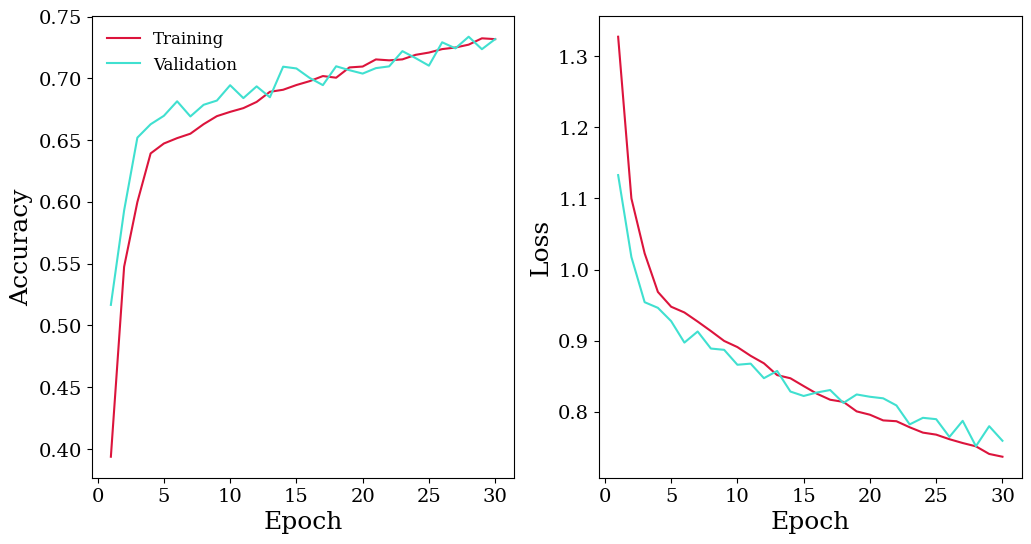

In [ ]:
loss_acc(history_images, 'img')

### 3.3 Evaluation Metrics 

The ROC curve shows how well the classifier separates one class from the others by plotting the true positive rate against the false positive rate at different decision thresholds. In this multi-class problem, a separate ROC curve is computed for each particle type using a one-vs-rest approach, furthermore a curve closer to the top-left corner indicates better discrimination, while the area under the curve (AUC) provides a summary of overall classification performance.


In [ ]:
#Take each image from the images_test array and predicts probability of belonging to each class
probabilities_images = model_images.predict(images_test)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


The probabilites array will be of shape (12000, 5) because there are 12,000 testing images (and labels) and 5 labels available. 

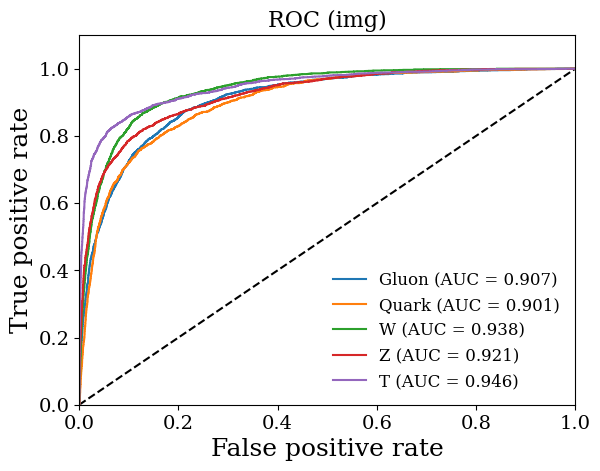

In [ ]:
labels_test_binarised = label_binarize(labels_test, classes=range(5))

roc_img = ROC(probabilities_images, 'img')

A confusion matrix is also included to show how the predicted labels compare with the true labels across all five particle categories; the diagonal entries correspond to correct classifications, while the off-diagonal entries highlight which particle types are most frequently misidentified as others. For a highly accurate model, the main diagonals will be the darkest and all the other elements will be very light. 

Accuracy for Gluon: 73.28%
Accuracy for Quark: 62.38%
Accuracy for W: 76.63%
Accuracy for Z: 69.61%
Accuracy for T: 78.53%


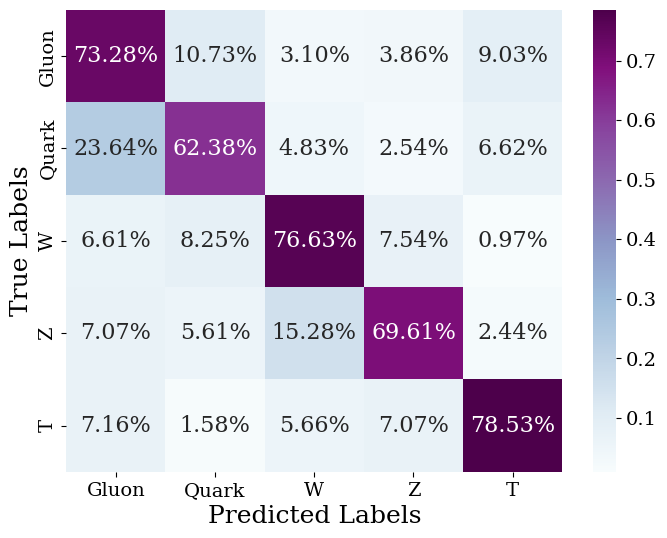

In [ ]:
img_pred_labels, img_acc = confusion_matrix(probabilities_images, 'img')

We can also view the report of the model, which shows the precision, recall and f1-score for each classification (here TP = true positive , FP = false positive, FN = false negative).

The precision is given by 
$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$
and measures the correct classifications against all classifications.

The recall is given by 
$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$
and measures the correct classification of a class.

The F1-score is an overall measure of how good the model is at correctly classifying classes, and is given by
$$\text{F1} = 2~ \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [313]:
report_img = classification_report(labels_test, img_pred_labels, target_names = particle_types)
print(report_img)

              precision    recall  f1-score   support

       Gluon       0.62      0.73      0.67      2358
       Quark       0.71      0.62      0.66      2403
           W       0.72      0.77      0.74      2375
           Z       0.77      0.70      0.73      2461
           T       0.81      0.79      0.80      2403

    accuracy                           0.72     12000
   macro avg       0.72      0.72      0.72     12000
weighted avg       0.73      0.72      0.72     12000



## 4. Task 2: Test your machine learning classifier and investigate how the efficiency of the classifier depends on the jet feature variables shown above. Which classes of event art the easiest to separate?

The files contain several jet features. These include:

| Feature      | Description |
| ----------- | ----------- |
| j_pt      | The transverse momentum of the jet   |
| j_eta      | The pseudorapidity of the jet  |
| j_mass     | The jet mass  |
| j_tau*   | A jet shape variable        |
| j_c*   | A jet shape variable        |
| j_multiplicity   | The number of particles in the jet      |
| j_zlogz | Splitting function |

A set of physically meaningful jet features was defined, including `'pt'`, `'eta'`, `'mass'`, `'mult'`, `'z'`, `'tau3_b1'`  in order to characterise different kinematic and substructure properties of the jets. 

To process these variables, I implemented the `get_features()` which reads each `.h5` file, extracts these scalar features using `h5py` and `pandas`, applies feature scaling, and separates the data by particle type (`gluon`, `quark`, `W`, `Z`, `top`).

The class labels for the training, validation, and test sets were subsequently transformed into one-hot encoded vectors via `to_categorical()`, converting each class index into a 5-dimensional binary vector and enabling the use of categorical crossentropy for multi-class classification.

I then implemented a custom function `create_scalar_model()` that builds a Multimodal Model Architecture (Image + Scalar Feature):

 - One branch processes **40x40 jet images** via **three convolutional layers and pooling layers**

 - Another branch processes **a single scalar jet feature** through **two dense layers**

 - The outputs from both branches are concatenated and passed through several dense layers to predict jet class probabilities

### 4.1 Jet features extraction and model definition

In [315]:
features = ['j_pt', 'j_eta', 'j_mass', 'j_zlogz', 'j_multiplicity', 'j_tau3_b1', 'j_d2_b2', 'j_d2_a1_b2', 
    'j_n2_b2', 'j_tau32_b1_mmdt', 'j_c1_b1_mmdt', 'j_c2_b1_mmdt', 'j_n2_b1_mmdt', 'j_mass_trim', 
            'j_mass_mmdt', 'j_mass_sdb2']

In [316]:
def get_features(filename):
    
    '''Function to extract data from h5 file 
    input: 
    filename: string, file path
    
    returns:
    scaled arrays of features'''

    if not os.path.isfile(filename):
        raise FileNotFoundError(f"File non trovato in locale: {filename}")
    with h5py.File(filename, 'r') as df:
        #Decode the labels for each column
        labels = [label.decode('utf-8') for label in df['jetFeatureNames'][:]]

        #Load the dataset into a DataFrame
        pJet = pd.DataFrame(np.array(df['jets']), columns=labels)

        #Initialize a dictionary to store scaled features
        scaled_features = {}

        for feature in features:
            feature_data = {}

            # Iterate over particle types
            for particle_type in ['g', 'q', 'w', 'z', 't']:
                # Filter rows based on the particle type
                data_particle = pJet[pJet[f'j_{particle_type}'] > 0]

                # Extract and scale the feature for the current particle type
                if feature in data_particle.columns:
                    feature_values = data_particle[feature].values.reshape(-1, 1)
                    scaled_values = scaler.fit_transform(feature_values).flatten()
                    feature_data[particle_type] = scaled_values
                else:
                    feature_data[particle_type] = np.array([])

            # Store the scaled feature data
            scaled_features[feature] = feature_data

    return scaled_features

In [317]:
def create_scalar_model(feature_name):
    
    #3 convolutional layers and pooling layers for the image input
    image_input = Input(shape=(40, 40, 1), name = 'image_input')
    
    x_image = Conv2D(32, (3, 3), activation='relu')(image_input)
    
    x_image = MaxPooling2D((2, 2))(x_image)
    
    x_image = Conv2D(64, (3, 3), activation = 'relu')(x_image)
    
    x_image = MaxPooling2D((2, 2))(x_image)
    
    x_image = Conv2D(64, (3, 3), activation = 'relu')(x_image)
    
    x_image = MaxPooling2D((2, 2))(x_image)
    
    x_image = Dropout(0.25)(x_image)
    
    x_image = Flatten()(x_image)

    #scalarinput for the jet feature input
    scalar_input = Input(shape = (1,), name = f'jet_{feature_name}_input')
    
    x_scalar = Dense(128, activation = 'relu')(scalar_input)
    
    x_scalar = Dense(64, activation = 'relu')(x_scalar)
    
    #Concatenating image and feature outputs
    concatenated = concatenate([x_image, x_scalar])
    
    x_combined = Dense(256, activation = 'relu')(concatenated)
    
    x_combined = Dense(128, activation = 'sigmoid')(x_combined)
    
    x_combined = Dense(64, activation = 'relu')(x_combined)
    
    x_combined = Dense(5, activation = 'softmax')(x_combined)
    
    model = Model(inputs = [image_input, scalar_input], outputs = x_combined)
    
    model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    
    model.summary()

    return model

#One hot encoding the labels
labels_train_onehot = to_categorical(labels_train, num_classes=5)
labels_val_onehot = to_categorical(labels_val, num_classes=5)
labels_test_onehot = to_categorical(labels_test, num_classes=5)

In [318]:
particle_types_f = ['g', 'q', 'w', 'z', 't'] 

#Dictionary to hold concatenated arrays for each feature and particle
concatenated_features = {feature: {ptype: [] for ptype in particle_types_f} for feature in features}

#Loop over files and features
for file_name in file_names:
    scaled_data = get_features(file_name)
    for feature in features:
        for ptype in particle_types_f:
            concatenated_features[feature][ptype].append(scaled_data[feature][ptype])

# Convert lists into array
for feature in concatenated_features:
    for ptype in concatenated_features[feature]:
        concatenated_features[feature][ptype] = np.concatenate(concatenated_features[feature][ptype])

### 4.2 Transverse Momentum


In [319]:
pt = np.concatenate([concatenated_features['j_pt']['g'], concatenated_features['j_pt']['q'],
                    concatenated_features['j_pt']['w'], concatenated_features['j_pt']['z'],
                    concatenated_features['j_pt']['t']])

In [320]:
pt_train, pt_temp = train_test_split(pt, test_size=0.3, random_state=69)
pt_val, pt_test = train_test_split(pt_temp, test_size=0.5, random_state=69)

In [321]:
model_pt = create_scalar_model('pt')

Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 38, 38,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_90    │ (None, 19, 19,    │          0 │ conv2d_90[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_91 (Conv2D)  │ (None, 17, 17,    │     18,496 │ max_pooling2d_90… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_91    │ (None, 8, 8, 64)  │          0 │ conv2d_91[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_92 (Conv2D)  │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_91… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_92    │ (None, 3, 3, 64)  │          0 │ conv2d_92[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jet_pt_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 3, 3, 64)  │          0 │ max_pooling2d_92… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_425 (Dense)   │ (None, 128)       │        256 │ jet_pt_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_30          │ (None, 576)       │          0 │ dropout_30[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_426 (Dense)   │ (None, 64)        │      8,256 │ dense_425[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_25      │ (None, 640)       │          0 │ flatten_30[0][0], │
│ (Concatenate)       │                   │            │ dense_426[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_427 (Dense)   │ (None, 256)       │    164,096 │ concatenate_25[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_428 (Dense)   │ (None, 128)       │     32,896 │ dense_427[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_429 (Dense)   │ (None, 64)        │      8,256 │ dense_428[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_430 (Dense)   │ (None, 5)         │        325 │ dense_429[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 269,829 (1.03 MB)

 Trainable params: 269,829 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_pt = model_pt.fit([images_train, pt_train], labels_train_onehot, epochs=epochs_number,
                    validation_data=([images_val, pt_val], labels_val_onehot), verbose=1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.5852 - loss: 1.0524 - val_accuracy: 0.6527 - val_loss: 0.9274
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.6471 - loss: 0.9213 - val_accuracy: 0.6470 - val_loss: 0.9074
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.6703 - loss: 0.8719 - val_accuracy: 0.6892 - val_loss: 0.8293
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6822 - loss: 0.8464 - val_accuracy: 0.7066 - val_loss: 0.8000
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.6895 - loss: 0.8278 - val_accuracy: 0.7107 - val_loss: 0.7904
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.6966 - loss: 0.8110 - val_accuracy: 0.7214 - val_loss: 0.7673
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7062 - loss: 0.7922 - val_accuracy: 0.7057 - val_loss: 0.8021
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.7111 - loss: 

The final accuracy was 0.7664 and the final loss was 0.6382


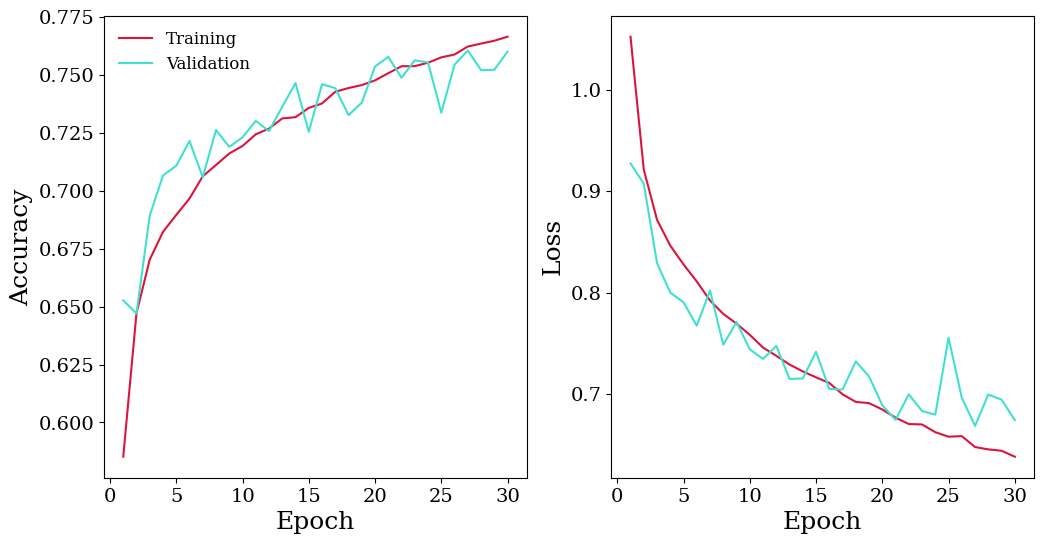

In [323]:
loss_acc(history_pt, 'pt')

In [324]:
probabilities_pt = model_pt.predict([images_test, pt_test])

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


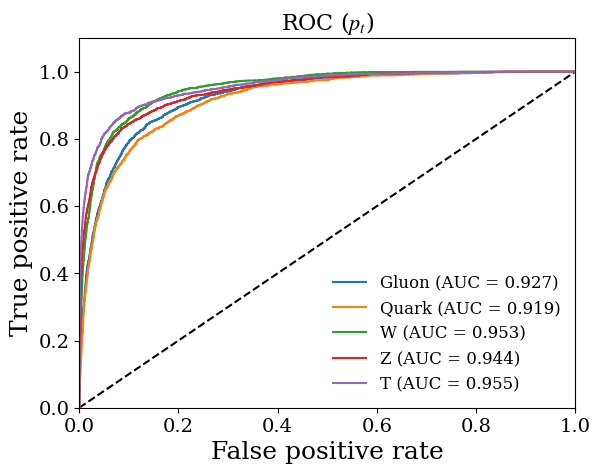

In [325]:
roc_pt = ROC(probabilities_pt, '$p_t$')

Accuracy for Gluon: 72.39%
Accuracy for Quark: 72.74%
Accuracy for W: 79.28%
Accuracy for Z: 75.50%
Accuracy for T: 77.49%


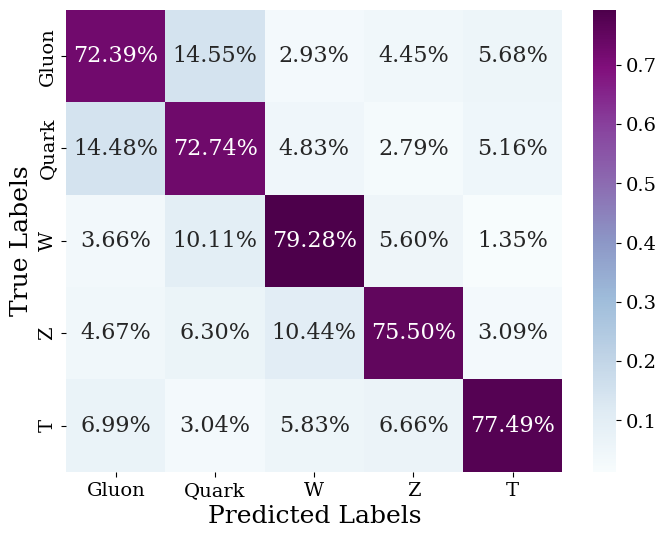

In [ ]:
pt_pred_labels, pt_acc = confusion_matrix(probabilities_pt, '$p_t$')

In [327]:
report_pt = classification_report(labels_test, pt_pred_labels, target_names = particle_types)
print(report_pt)

              precision    recall  f1-score   support

       Gluon       0.70      0.72      0.71      2358
       Quark       0.68      0.73      0.70      2403
           W       0.76      0.79      0.78      2375
           Z       0.80      0.75      0.78      2461
           T       0.84      0.77      0.80      2403

    accuracy                           0.75     12000
   macro avg       0.76      0.75      0.76     12000
weighted avg       0.76      0.75      0.76     12000



### 4.3 Pseudorapidity

In [328]:
eta = np.concatenate([concatenated_features['j_eta']['g'], concatenated_features['j_eta']['q'],
                    concatenated_features['j_eta']['w'], concatenated_features['j_eta']['z'],
                    concatenated_features['j_eta']['t']])

In [329]:
eta_train, eta_temp = train_test_split(eta, test_size=0.3, random_state=69)
eta_val, eta_test = train_test_split(eta_temp, test_size=0.5, random_state=69)

In [330]:
model_eta = create_scalar_model('eta')

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_93 (Conv2D)  │ (None, 38, 38,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_93    │ (None, 19, 19,    │          0 │ conv2d_93[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 17, 17,    │     18,496 │ max_pooling2d_93… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_94    │ (None, 8, 8, 64)  │          0 │ conv2d_94[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_94… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_95    │ (None, 3, 3, 64)  │          0 │ conv2d_95[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jet_eta_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 3, 3, 64)  │          0 │ max_pooling2d_95… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_431 (Dense)   │ (None, 128)       │        256 │ jet_eta_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_31          │ (None, 576)       │          0 │ dropout_31[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_432 (Dense)   │ (None, 64)        │      8,256 │ dense_431[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_26      │ (None, 640)       │          0 │ flatten_31[0][0], │
│ (Concatenate)       │                   │            │ dense_432[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_433 (Dense)   │ (None, 256)       │    164,096 │ concatenate_26[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_434 (Dense)   │ (None, 128)       │     32,896 │ dense_433[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_435 (Dense)   │ (None, 64)        │      8,256 │ dense_434[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_436 (Dense)   │ (None, 5)         │        325 │ dense_435[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 269,829 (1.03 MB)

 Trainable params: 269,829 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_eta = model_eta.fit([images_train, eta_train], labels_train_onehot, epochs = epochs_number,
                    validation_data = ([images_val, eta_val], labels_val_onehot), verbose = 1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.5727 - loss: 1.0906 - val_accuracy: 0.5932 - val_loss: 1.0560
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.6261 - loss: 0.9836 - val_accuracy: 0.6557 - val_loss: 0.9372
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.6422 - loss: 0.9461 - val_accuracy: 0.6402 - val_loss: 0.9417
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.6534 - loss: 0.9218 - val_accuracy: 0.6643 - val_loss: 0.8940
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.6607 - loss: 0.9000 - val_accuracy: 0.6803 - val_loss: 0.8666
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.6699 - loss: 0.8831 - val_accuracy: 0.6769 - val_loss: 0.8612
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.6760 - loss: 0.8681 - val_accuracy: 0.6915 - val_loss: 0.8501
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.6807 -

The final accuracy was 0.7474 and the final loss was 0.6918


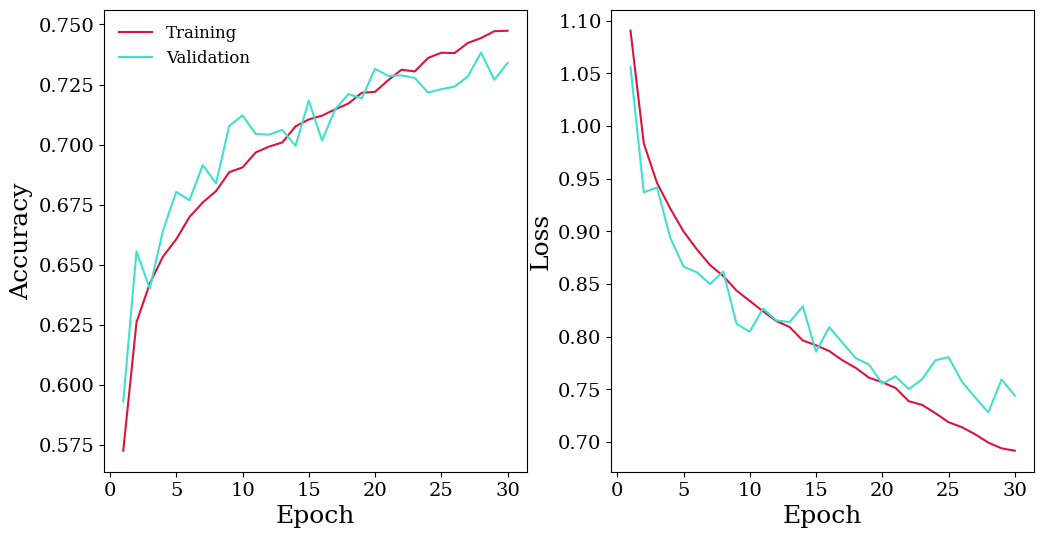

In [332]:
loss_acc(history_eta, 'eta')

 22/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:2: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/var/folders/hh/ckf9mcl97j76pk99xnd7192r0000gn/T/ipykernel_51374/3059992183.py:2: SyntaxWarning: invalid escape sequence '\e'
  roc_eta = ROC(probabilities_eta, '$\eta$')
/var/folders/hh/ckf9mcl97j76pk99xnd7192r0000gn/T/ipykernel_51374/3059992183.py:3: SyntaxWarning: invalid escape sequence '\e'
  eta_pred_labels, eta_acc = conf(probabilities_eta, '$\eta$')


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for Gluon: 63.70%
Accuracy for Quark: 73.33%
Accuracy for W: 77.05%
Accuracy for Z: 72.25%
Accuracy for T: 76.82%


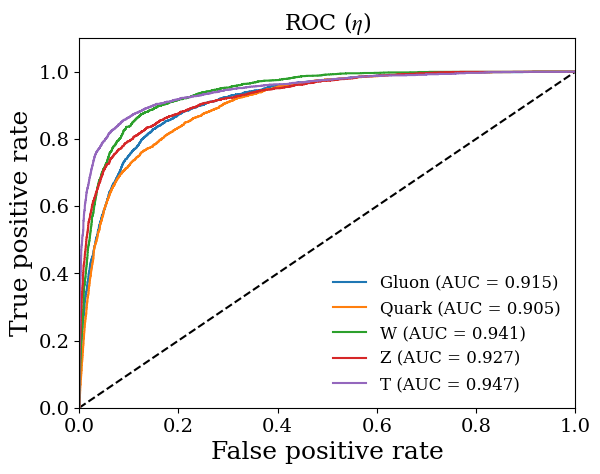

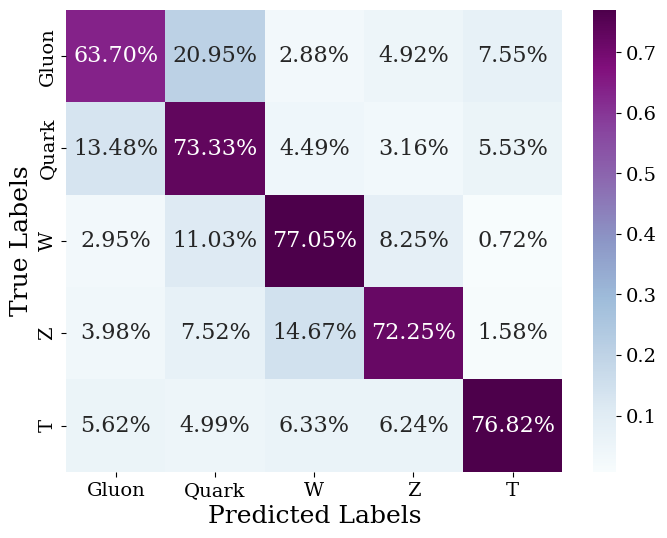

In [ ]:
probabilities_eta = model_eta.predict([images_test, eta_test])
roc_eta = ROC(probabilities_eta, '$\eta$')
eta_pred_labels, eta_acc = confusion_matrix(probabilities_eta, '$\eta$')

In [334]:
report_eta = classification_report(labels_test, eta_pred_labels, target_names = particle_types)
print(report_eta)

              precision    recall  f1-score   support

       Gluon       0.71      0.64      0.67      2358
       Quark       0.62      0.73      0.67      2403
           W       0.73      0.77      0.75      2375
           Z       0.77      0.72      0.74      2461
           T       0.83      0.77      0.80      2403

    accuracy                           0.73     12000
   macro avg       0.73      0.73      0.73     12000
weighted avg       0.73      0.73      0.73     12000



### 4.4 Mass

In [335]:
mass = np.concatenate([concatenated_features['j_mass']['g'], concatenated_features['j_mass']['q'],
                    concatenated_features['j_mass']['w'], concatenated_features['j_mass']['z'],
                    concatenated_features['j_mass']['t']])

In [336]:
mass_train, mass_temp = train_test_split(mass, test_size=0.3, random_state=69)
mass_val, mass_test = train_test_split(mass_temp, test_size=0.5, random_state=69)

In [337]:
model_mass = create_scalar_model('mass')

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 38, 38,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_96    │ (None, 19, 19,    │          0 │ conv2d_96[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 17, 17,    │     18,496 │ max_pooling2d_96… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_97    │ (None, 8, 8, 64)  │          0 │ conv2d_97[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_97… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_98    │ (None, 3, 3, 64)  │          0 │ conv2d_98[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jet_mass_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_32          │ (None, 3, 3, 64)  │          0 │ max_pooling2d_98… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_437 (Dense)   │ (None, 128)       │        256 │ jet_mass_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_32          │ (None, 576)       │          0 │ dropout_32[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_438 (Dense)   │ (None, 64)        │      8,256 │ dense_437[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_27      │ (None, 640)       │          0 │ flatten_32[0][0], │
│ (Concatenate)       │                   │            │ dense_438[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_439 (Dense)   │ (None, 256)       │    164,096 │ concatenate_27[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_440 (Dense)   │ (None, 128)       │     32,896 │ dense_439[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_441 (Dense)   │ (None, 64)        │      8,256 │ dense_440[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_442 (Dense)   │ (None, 5)         │        325 │ dense_441[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 269,829 (1.03 MB)

 Trainable params: 269,829 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_mass = model_mass.fit([images_train, mass_train], labels_train_onehot, epochs = epochs_number,
                    validation_data = ([images_val, mass_val], labels_val_onehot), verbose = 1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.6568 - loss: 0.8096 - val_accuracy: 0.7335 - val_loss: 0.6601
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7302 - loss: 0.6451 - val_accuracy: 0.7499 - val_loss: 0.6195
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7551 - loss: 0.5898 - val_accuracy: 0.7592 - val_loss: 0.5745
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7700 - loss: 0.5542 - val_accuracy: 0.8001 - val_loss: 0.4963
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7788 - loss: 0.5356 - val_accuracy: 0.8021 - val_loss: 0.5012
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7919 - loss: 0.5096 - val_accuracy: 0.8222 - val_loss: 0.4521
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.7969 - loss: 0.4947 - val_accuracy: 0.8118 - val_loss: 0.4700
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.8054 -

The final accuracy was 0.8715 and the final loss was 0.3195


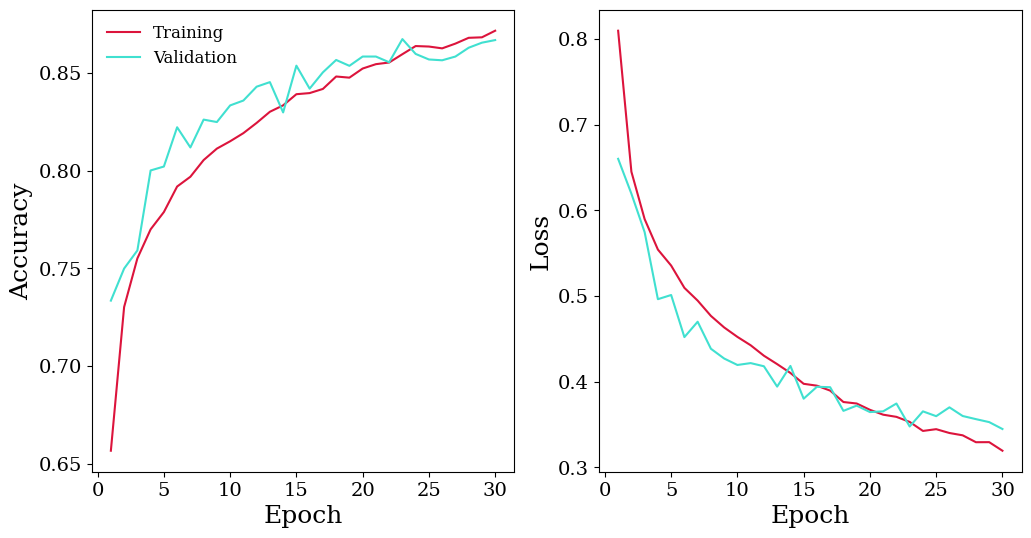

In [339]:
loss_acc(history_mass, 'mass')

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for Gluon: 80.92%
Accuracy for Quark: 91.09%
Accuracy for W: 88.76%
Accuracy for Z: 74.28%
Accuracy for T: 98.04%


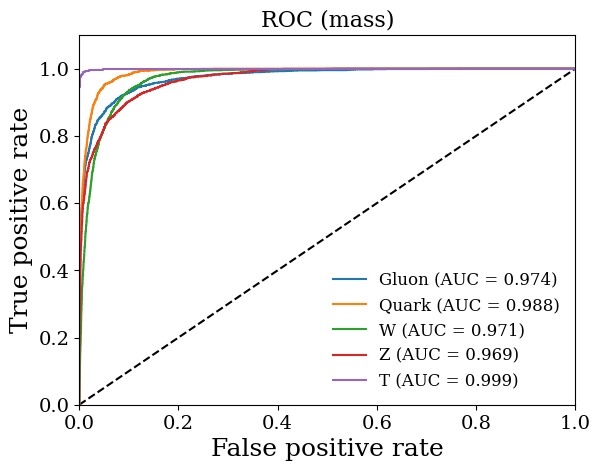

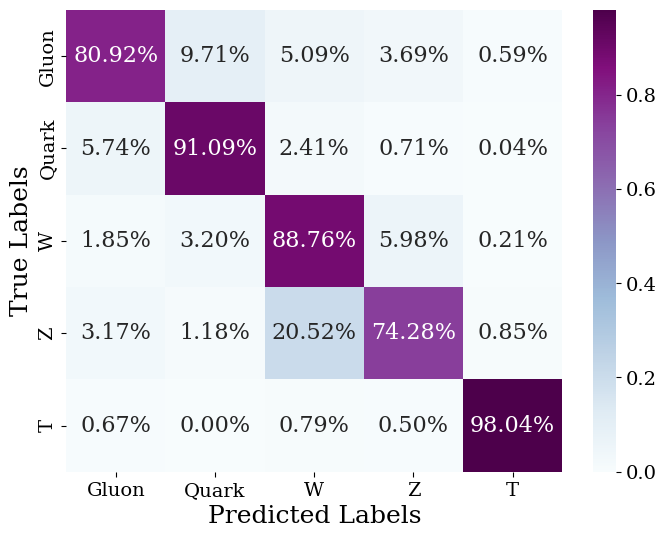

In [ ]:
probabilities_mass = model_mass.predict([images_test, mass_test])
roc_mass = ROC(probabilities_mass, 'mass')
mass_pred_labels, mass_acc = confusion_matrix(probabilities_mass, 'mass')

In [341]:
report_mass = classification_report(labels_test, mass_pred_labels, target_names = particle_types)
print(report_mass)

              precision    recall  f1-score   support

       Gluon       0.87      0.81      0.84      2358
       Quark       0.87      0.91      0.89      2403
           W       0.75      0.89      0.81      2375
           Z       0.88      0.74      0.80      2461
           T       0.98      0.98      0.98      2403

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     12000
weighted avg       0.87      0.87      0.87     12000



### 4.5 Multiplicity

In [342]:
mult = np.concatenate([concatenated_features['j_multiplicity']['g'], 
                       concatenated_features['j_multiplicity']['q'],
                       concatenated_features['j_multiplicity']['w'], 
                       concatenated_features['j_multiplicity']['z'],
                       concatenated_features['j_multiplicity']['t']])

In [343]:
mult_train, mult_temp = train_test_split(mult, test_size=0.3, random_state=69)
mult_val, mult_test = train_test_split(mult_temp, test_size=0.5, random_state=69)

In [344]:
model_mult = create_scalar_model('mult')

Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_99 (Conv2D)  │ (None, 38, 38,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_99    │ (None, 19, 19,    │          0 │ conv2d_99[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_100 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_99… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_100   │ (None, 8, 8, 64)  │          0 │ conv2d_100[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_101 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_101   │ (None, 3, 3, 64)  │          0 │ conv2d_101[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jet_mult_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 3, 3, 64)  │          0 │ max_pooling2d_10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_443 (Dense)   │ (None, 128)       │        256 │ jet_mult_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_33          │ (None, 576)       │          0 │ dropout_33[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_444 (Dense)   │ (None, 64)        │      8,256 │ dense_443[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_28      │ (None, 640)       │          0 │ flatten_33[0][0], │
│ (Concatenate)       │                   │            │ dense_444[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_445 (Dense)   │ (None, 256)       │    164,096 │ concatenate_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_446 (Dense)   │ (None, 128)       │     32,896 │ dense_445[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_447 (Dense)   │ (None, 64)        │      8,256 │ dense_446[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_448 (Dense)   │ (None, 5)         │        325 │ dense_447[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 269,829 (1.03 MB)

 Trainable params: 269,829 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_mult = model_mult.fit([images_train, mult_train], labels_train_onehot, epochs = epochs_number,
                    validation_data = ([images_val, mult_val], labels_val_onehot), verbose = 1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5814 - loss: 1.0512 - val_accuracy: 0.6316 - val_loss: 0.9582
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.6484 - loss: 0.9121 - val_accuracy: 0.6758 - val_loss: 0.8445
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.6843 - loss: 0.8264 - val_accuracy: 0.7203 - val_loss: 0.7629
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7125 - loss: 0.7610 - val_accuracy: 0.7343 - val_loss: 0.7203
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7348 - loss: 0.7070 - val_accuracy: 0.7628 - val_loss: 0.6522
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7518 - loss: 0.6610 - val_accuracy: 0.7719 - val_loss: 0.6181
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7677 - loss: 0.6182 - val_accuracy: 0.7632 - val_loss: 0.6319
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.7778 -

The final accuracy was 0.8501 and the final loss was 0.3973


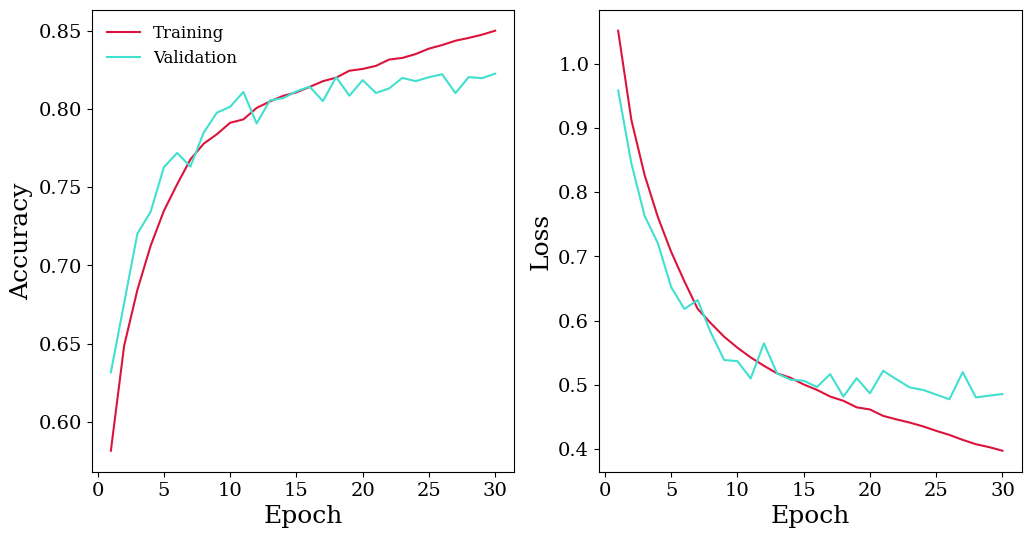

In [346]:
loss_acc(history_mult, 'mult')

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for Gluon: 87.57%
Accuracy for Quark: 83.77%
Accuracy for W: 78.36%
Accuracy for Z: 74.28%
Accuracy for T: 88.47%


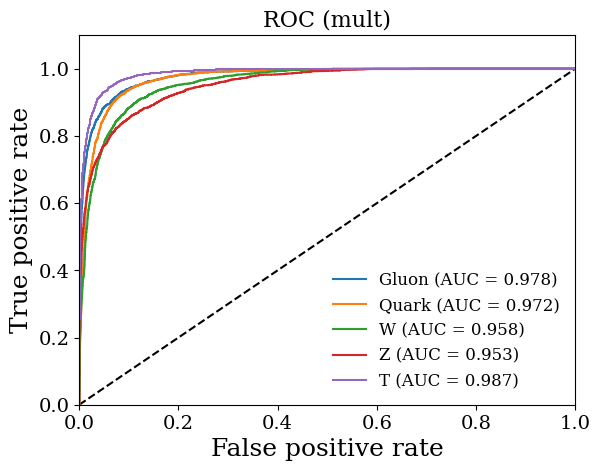

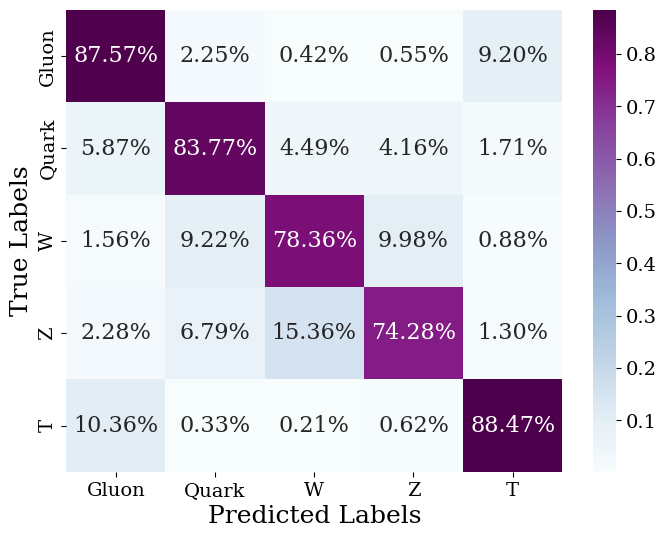

In [ ]:
probabilities_mult = model_mult.predict([images_test, mult_test])
roc_mult = ROC(probabilities_mult, 'mult')
mult_pred_labels, mult_acc = confusion_matrix(probabilities_mult, 'mult')

In [348]:
report_mult = classification_report(labels_test, mult_pred_labels, target_names = particle_types)
print(report_mult)

              precision    recall  f1-score   support

       Gluon       0.81      0.88      0.84      2358
       Quark       0.82      0.84      0.83      2403
           W       0.79      0.78      0.79      2375
           Z       0.83      0.74      0.79      2461
           T       0.87      0.88      0.88      2403

    accuracy                           0.82     12000
   macro avg       0.82      0.82      0.82     12000
weighted avg       0.82      0.82      0.82     12000



### 4.6 Splitting

In [349]:
z = np.concatenate([concatenated_features['j_zlogz']['g'], 
                       concatenated_features['j_zlogz']['q'],
                       concatenated_features['j_zlogz']['w'], 
                       concatenated_features['j_zlogz']['z'],
                       concatenated_features['j_zlogz']['t']])

In [350]:
z_train, z_temp = train_test_split(z, test_size=0.3, random_state=69)
z_val, z_test = train_test_split(z_temp, test_size=0.5, random_state=69)

In [351]:
model_z = create_scalar_model('zlogz')

Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_102 (Conv2D) │ (None, 38, 38,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_102   │ (None, 19, 19,    │          0 │ conv2d_102[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_103 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_103   │ (None, 8, 8, 64)  │          0 │ conv2d_103[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_104 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_104   │ (None, 3, 3, 64)  │          0 │ conv2d_104[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jet_zlogz_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 3, 3, 64)  │          0 │ max_pooling2d_10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_449 (Dense)   │ (None, 128)       │        256 │ jet_zlogz_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_34          │ (None, 576)       │          0 │ dropout_34[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_450 (Dense)   │ (None, 64)        │      8,256 │ dense_449[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_29      │ (None, 640)       │          0 │ flatten_34[0][0], │
│ (Concatenate)       │                   │            │ dense_450[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_451 (Dense)   │ (None, 256)       │    164,096 │ concatenate_29[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_452 (Dense)   │ (None, 128)       │     32,896 │ dense_451[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_453 (Dense)   │ (None, 64)        │      8,256 │ dense_452[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_454 (Dense)   │ (None, 5)         │        325 │ dense_453[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 269,829 (1.03 MB)

 Trainable params: 269,829 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_z = model_z.fit([images_train, z_train], labels_train_onehot, epochs = epochs_number,
                    validation_data = ([images_val, z_val], labels_val_onehot), verbose = 1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5779 - loss: 1.0557 - val_accuracy: 0.6579 - val_loss: 0.9032
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.6595 - loss: 0.8893 - val_accuracy: 0.7111 - val_loss: 0.7849
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.6994 - loss: 0.7990 - val_accuracy: 0.7213 - val_loss: 0.7665
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7195 - loss: 0.7484 - val_accuracy: 0.7538 - val_loss: 0.6799
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7313 - loss: 0.7205 - val_accuracy: 0.7490 - val_loss: 0.6832
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7378 - loss: 0.7011 - val_accuracy: 0.7639 - val_loss: 0.6583
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7489 - loss: 0.6786 - val_accuracy: 0.7573 - val_loss: 0.6535
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.7542 -

The final accuracy was 0.8243 and the final loss was 0.4802


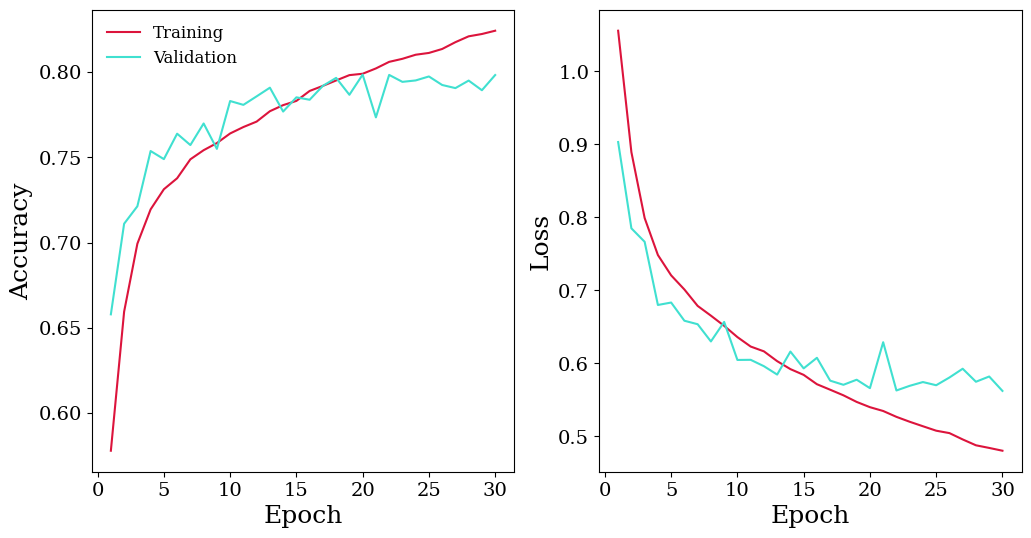

In [353]:
loss_acc(history_z, 'zlogz')

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for Gluon: 79.73%
Accuracy for Quark: 82.19%
Accuracy for W: 74.91%
Accuracy for Z: 74.20%
Accuracy for T: 86.39%


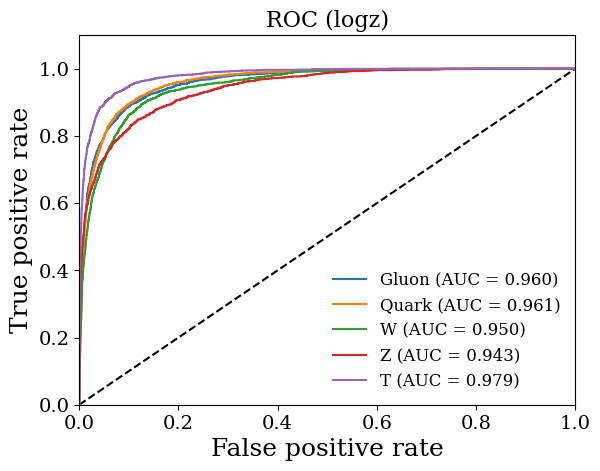

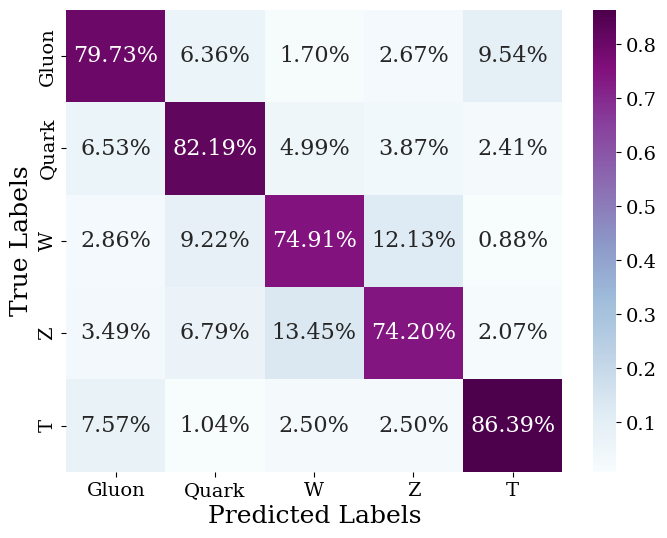

In [ ]:
probabilities_z = model_z.predict([images_test, z_test])
roc_z = ROC(probabilities_z, 'logz')
z_pred_labels, z_acc = confusion_matrix(probabilities_z, 'zlogz')

In [355]:
report_z = classification_report(labels_test, z_pred_labels, target_names = particle_types)
print(report_z)

              precision    recall  f1-score   support

       Gluon       0.79      0.80      0.79      2358
       Quark       0.78      0.82      0.80      2403
           W       0.76      0.75      0.76      2375
           Z       0.78      0.74      0.76      2461
           T       0.85      0.86      0.86      2403

    accuracy                           0.79     12000
   macro avg       0.79      0.79      0.79     12000
weighted avg       0.79      0.79      0.79     12000



### 4.7 Substructure Variable Tau3_b1

In [356]:
tau3_b1 = np.concatenate([concatenated_features['j_tau3_b1']['g'], 
                          concatenated_features['j_tau3_b1']['q'],
                          concatenated_features['j_tau3_b1']['w'], 
                          concatenated_features['j_tau3_b1']['z'],
                          concatenated_features['j_tau3_b1']['t']])

In [357]:
tau3_b1_train, tau3_b1_temp = train_test_split(tau3_b1, test_size=0.3, random_state=69)
tau3_b1_val, tau3_b1_test = train_test_split(tau3_b1_temp, test_size=0.5, random_state=69)

In [358]:
model_tau3_b1 = create_scalar_model('tau3_b1')

Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_105 (Conv2D) │ (None, 38, 38,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_105   │ (None, 19, 19,    │          0 │ conv2d_105[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_106 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_106   │ (None, 8, 8, 64)  │          0 │ conv2d_106[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_107 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_107   │ (None, 3, 3, 64)  │          0 │ conv2d_107[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jet_tau3_b1_input   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_35          │ (None, 3, 3, 64)  │          0 │ max_pooling2d_10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_455 (Dense)   │ (None, 128)       │        256 │ jet_tau3_b1_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_35          │ (None, 576)       │          0 │ dropout_35[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_456 (Dense)   │ (None, 64)        │      8,256 │ dense_455[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_30      │ (None, 640)       │          0 │ flatten_35[0][0], │
│ (Concatenate)       │                   │            │ dense_456[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_457 (Dense)   │ (None, 256)       │    164,096 │ concatenate_30[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_458 (Dense)   │ (None, 128)       │     32,896 │ dense_457[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_459 (Dense)   │ (None, 64)        │      8,256 │ dense_458[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_460 (Dense)   │ (None, 5)         │        325 │ dense_459[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 269,829 (1.03 MB)

 Trainable params: 269,829 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_tau3_b1 = model_tau3_b1.fit([images_train, tau3_b1_train], labels_train_onehot, epochs = epochs_number,
                    validation_data = ([images_val, tau3_b1_val], labels_val_onehot), verbose = 1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.5848 - loss: 1.0346 - val_accuracy: 0.6607 - val_loss: 0.8890
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.6603 - loss: 0.8768 - val_accuracy: 0.6705 - val_loss: 0.8648
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.6996 - loss: 0.7887 - val_accuracy: 0.7297 - val_loss: 0.7280
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7343 - loss: 0.7033 - val_accuracy: 0.7197 - val_loss: 0.7357
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.7563 - loss: 0.6502 - val_accuracy: 0.7873 - val_loss: 0.5739
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.7673 - loss: 0.6204 - val_accuracy: 0.7799 - val_loss: 0.5796
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7785 - loss: 0.5920 - val_accuracy: 0.7863 - val_loss: 0.5596
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.7878 -

The final accuracy was 0.8585 and the final loss was 0.3740


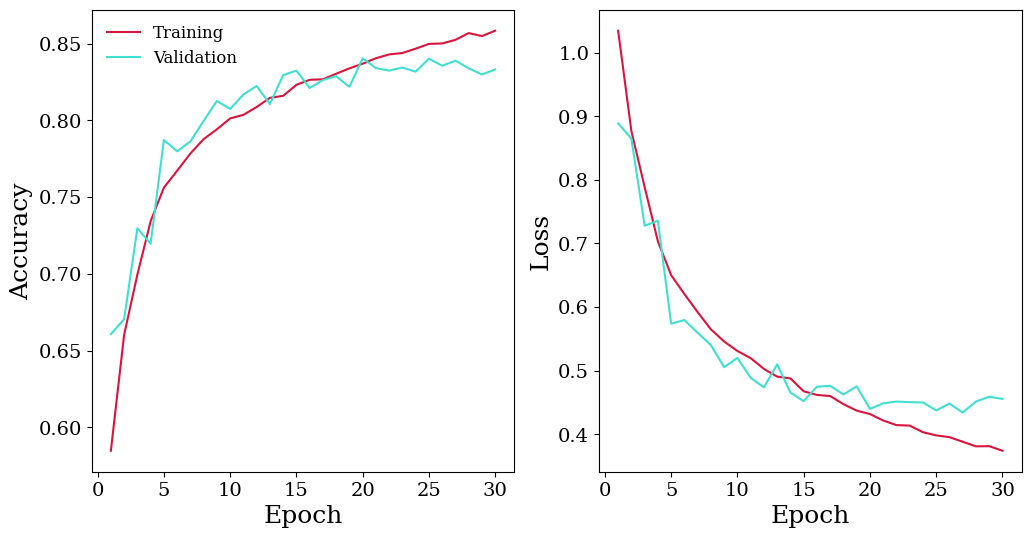

In [360]:
loss_acc(history_tau3_b1, 'tau3_b1')

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for Gluon: 86.43%
Accuracy for Quark: 86.06%
Accuracy for W: 79.41%
Accuracy for Z: 76.35%
Accuracy for T: 88.06%


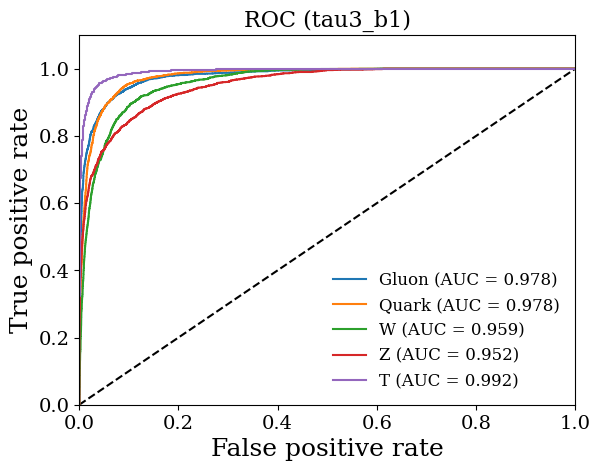

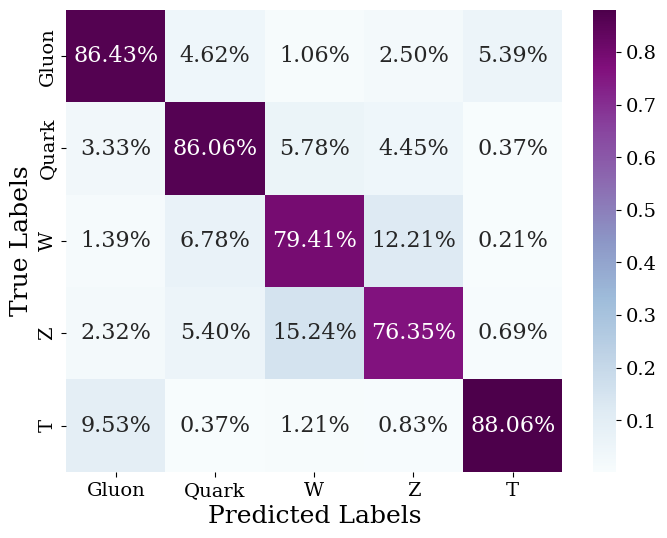

In [ ]:
probabilities_tau3_b1 = model_tau3_b1.predict([images_test, tau3_b1_test])
roc_tau3_b1 = ROC(probabilities_tau3_b1, 'tau3_b1')
tau3_b1_pred_labels, tau3_b1_acc = confusion_matrix(probabilities_tau3_b1, 'tau3_b1')

In [362]:
report_tau3_b1 = classification_report(labels_test, tau3_b1_pred_labels, target_names = particle_types)
print(report_tau3_b1)

              precision    recall  f1-score   support

       Gluon       0.84      0.86      0.85      2358
       Quark       0.83      0.86      0.85      2403
           W       0.77      0.79      0.78      2375
           Z       0.80      0.76      0.78      2461
           T       0.93      0.88      0.90      2403

    accuracy                           0.83     12000
   macro avg       0.83      0.83      0.83     12000
weighted avg       0.83      0.83      0.83     12000



### 4.8 Which classes of events are easiest to separate?

In [ ]:
training_cats = ['Images', r'$p_t$', r'$\eta$', 'Mass', 'Mult.', '$z\log z$', r'$\tau_3$']

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hh/ckf9mcl97j76pk99xnd7192r0000gn/T/ipykernel_51374/3708390103.py:1: SyntaxWarning: invalid escape sequence '\l'
  training_cats = ['Images', r'$p_t$', r'$\eta$', 'Mass', 'Mult.', '$z\log z$', r'$\tau_3$']


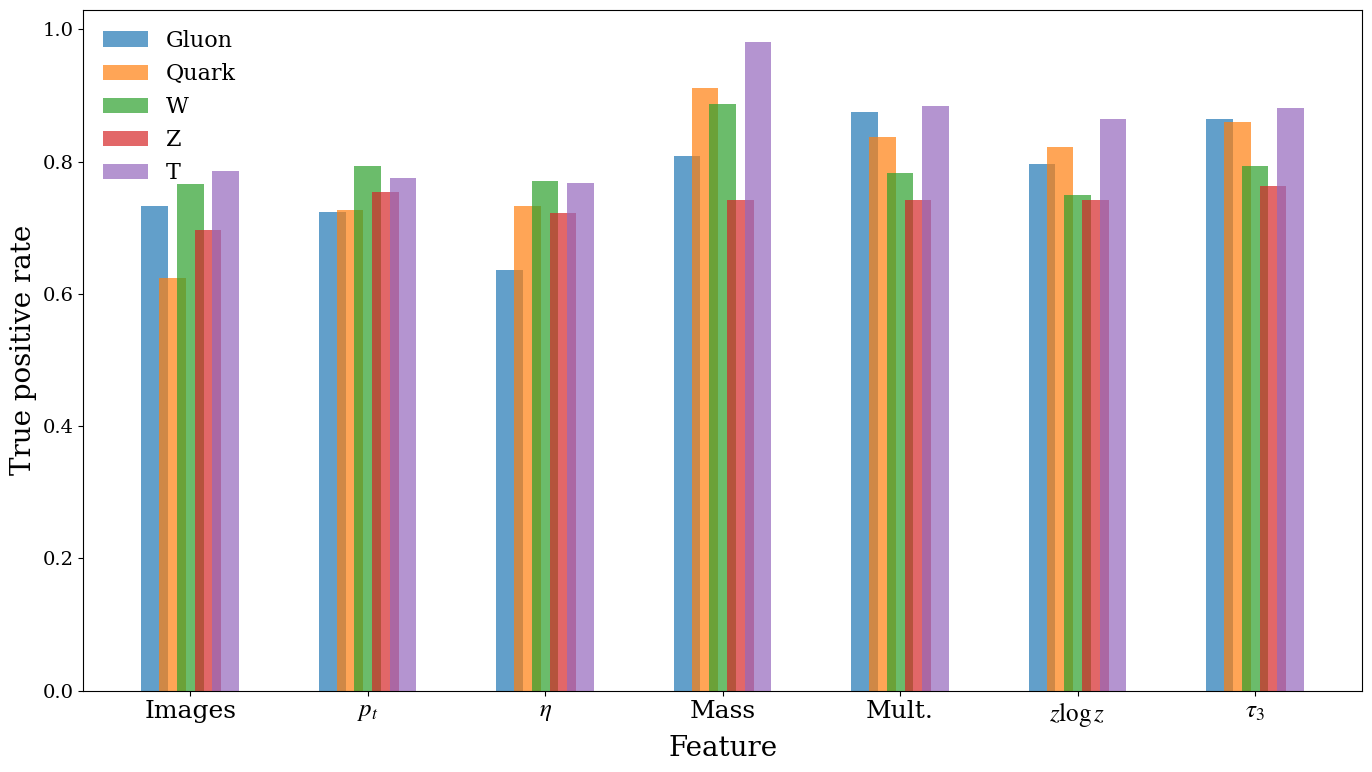

In [ ]:
group_names = training_cats
bar_labels = particle_types

# Random data generation for demonstration purposes
data = np.stack([img_acc, pt_acc, eta_acc, mass_acc, mult_acc, z_acc, tau3_b1_acc])   

# Configurations for the bar positions
bar_width = 0.15
index = np.arange(7)
offsets = np.linspace(-0.2, 0.2, 5)

# Plotting the bars
fig, ax = plt.subplots(figsize=(14,8))
for i, offset in enumerate(offsets):
    ax.bar(index + offset, data[:, i], bar_width, label=bar_labels[i], alpha=0.7)

# Adding some presentation aspects
ax.set_xlabel('Feature', fontsize=20)
ax.set_ylabel('True positive rate', fontsize=20)
ax.set_xticks(index)
ax.set_xticklabels(group_names, fontsize=18)
ax.legend(loc='best', frameon= False, fontsize=16)

# Showing the plot
plt.tight_layout()
plt.savefig('Depend.pdf', dpi = 1000)
plt.show()


This final comparison suggests that the six scalar features provide class-dependent improvements in discrimination performance, rather than a uniform gain across all jet categories. In particular, jet mass appears to be the most informative single observable overall, yielding the strongest true positive rates for quark, **W**, and especially top jets (this is because there is large differences in the masses of each type of particle); $z \log z$ and $\tau$ also show strong discriminative power across several classes, whereas pseudorapidity $\eta$ has the least significant contribute. The results also indicate that image-only classification is already competitive, yet selected scalar observables can enhance separability for specific particle types when their physical information is particularly relevant. Overall, this analysis supports the conclusion that scalar features are not equally useful, and that a small subset of physically meaningful observables can substantially improve classification performance for certain jet classes.



### 4.9 Additional Experiment: combined features analysis

Having first examined the contribution of each scalar feature individually by combining it with the jet image input, I now extend the analysis by incorporating all previously selected scalar features into a single image-based classifier. This more complete framework makes it possible to evaluate whether the joint use of multiple physically meaningful observables can provide additional discriminative power beyond that obtained from each feature separately. In this way, the model can capture complementary information and potentially achieve improved classification performance across the different jet classes.

In [ ]:
#Now making a model using the jet image + the 5 features
image_input = Input(shape=(40, 40, 1), name='image_input')
x_image = Conv2D(32, (3, 3), activation='relu')(image_input)
x_image = MaxPooling2D((2, 2))(x_image)
x_image = Conv2D(64, (3, 3), activation='relu')(x_image)
x_image = MaxPooling2D((2, 2))(x_image)
x_image = Conv2D(64, (3, 3), activation='relu')(x_image)
x_image = MaxPooling2D((2, 2))(x_image)
x_image = Dropout(0.25)(x_image)
x_image = Flatten()(x_image)

#The features
pt_input = Input(shape=(1,), name='pt_input')
x_pt = Dense(128, activation = 'relu')(pt_input)
x_pt = Dense(64, activation = 'relu')(x_pt)

eta_input = Input(shape=(1,), name='eta_input')
x_eta = Dense(128, activation = 'relu')(eta_input)
x_eta = Dense(64, activation = 'relu')(x_eta)

mass_input = Input(shape=(1,), name='mass_input')
x_mass = Dense(128, activation = 'relu')(mass_input)
x_mass = Dense(64, activation = 'relu')(x_mass)

mult_input = Input(shape=(1,), name='mult_input')
x_mult = Dense(128, activation = 'relu')(mult_input)
x_mult = Dense(64, activation = 'relu')(x_mult)

z_input = Input(shape=(1,), name='zlogz_input')
x_z = Dense(128, activation = 'relu')(z_input)
x_z = Dense(64, activation = 'relu')(x_z)

tau3_b1_input = Input(shape=(1,), name='tau3_b1_input')
x_tau3_b1 = Dense(128, activation = 'relu')(tau3_b1_input)
x_tau3_b1 = Dense(64, activation = 'relu')(x_tau3_b1)

concatenated = concatenate([x_image, x_pt, x_eta, x_mass, x_mult, x_z, x_tau3_b1])

x_combined = Dense(256, activation='relu')(concatenated)
x_combined = Dense(128, activation='sigmoid')(x_combined)
x_combined = Dense(64, activation='relu')(x_combined)
x_combined = Dense(5, activation='softmax')(x_combined)

model_images_6features = Model(inputs=[image_input, pt_input, eta_input, mass_input, mult_input, z_input, tau3_b1_input], 
                  outputs=x_combined)

model_images_6features.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_images_6features.summary()


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_108 (Conv2D) │ (None, 38, 38,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_108   │ (None, 19, 19,    │          0 │ conv2d_108[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_109 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_109   │ (None, 8, 8, 64)  │          0 │ conv2d_109[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_110 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_10… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_110   │ (None, 3, 3, 64)  │          0 │ conv2d_110[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pt_input            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mult_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zlogz_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tau3_b1_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 3, 3, 64)  │          0 │ max_pooling2d_11… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_461 (Dense)   │ (None, 128)       │        256 │ pt_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_463 (Dense)   │ (None, 128)       │        256 │ eta_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_465 (Dense)   │ (None, 128)       │        256 │ mass_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_467 (Dense)   │ (None, 128)       │        256 │ mult_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 394,309 (1.50 MB)

 Trainable params: 394,309 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_images_6features = model_images_6features.fit([images_train, eta_train, pt_train, mass_train, mult_train, z_train, tau3_b1_train], 
                    labels_train_onehot, epochs = epochs_number,
                    validation_data = ([images_val, eta_val, pt_val, mass_val, mult_val, z_val, tau3_b1_val], 
                    labels_val_onehot), verbose=1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.7061 - loss: 0.6956 - val_accuracy: 0.8057 - val_loss: 0.4667
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.8037 - loss: 0.4731 - val_accuracy: 0.8182 - val_loss: 0.4343
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8333 - loss: 0.4045 - val_accuracy: 0.8682 - val_loss: 0.3291
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8489 - loss: 0.3669 - val_accuracy: 0.8717 - val_loss: 0.3269
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8634 - loss: 0.3345 - val_accuracy: 0.8728 - val_loss: 0.3134
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - accuracy: 0.8719 - loss: 0.3142 - val_accuracy: 0.8855 - val_loss: 0.2850
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.8807 - loss: 0.2940 - val_accuracy: 0.9032 - val_loss: 0.2489
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.8844 -

The final accuracy was 0.9312 and the final loss was 0.1685


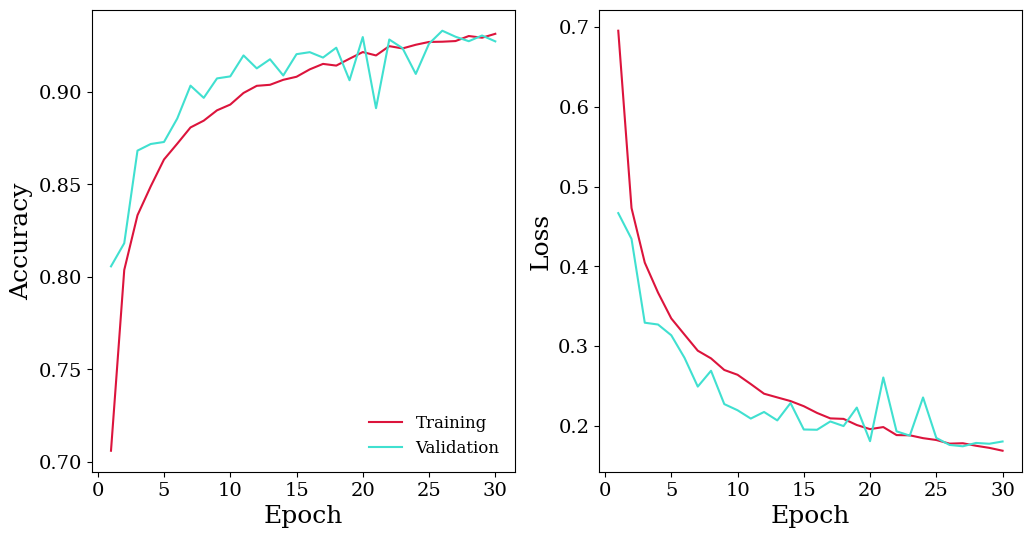

In [ ]:
loss_acc(history_images_6features, 'all')

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for Gluon: 98.13%
Accuracy for Quark: 91.39%
Accuracy for W: 84.46%
Accuracy for Z: 87.48%
Accuracy for T: 99.67%


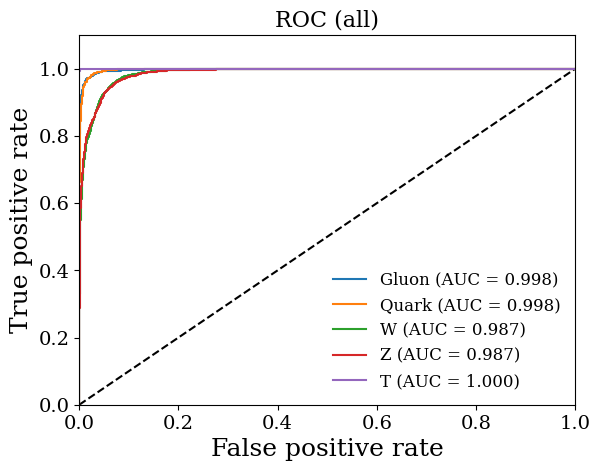

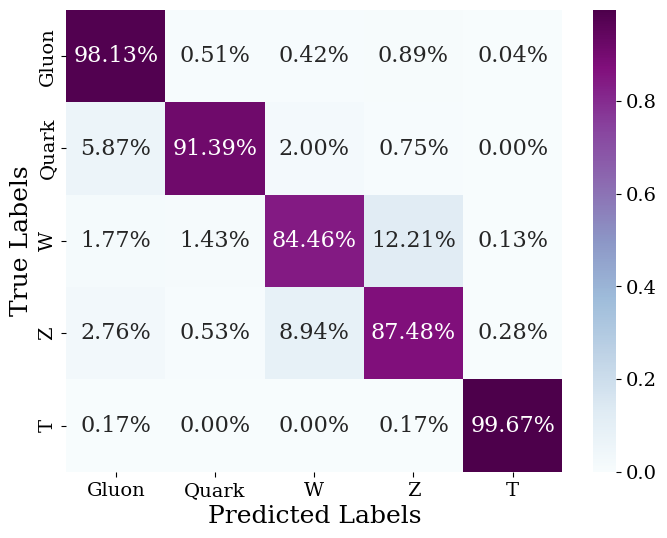

In [ ]:
probabilities_images_6features = model_images_6features.predict([images_test, eta_test, pt_test, mass_test, mult_test, z_test, tau3_b1_test])
roc_images_6features = ROC(probabilities_images_6features, 'all')
img6_pred_labels, img6_acc = confusion_matrix(probabilities_images_6features, 'all')

<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:47: SyntaxWarning: invalid escape sequence '\l'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:47: SyntaxWarning: invalid escape sequence '\l'
/var/folders/hh/ckf9mcl97j76pk99xnd7192r0000gn/T/ipykernel_51374/1741542804.py:38: SyntaxWarning: invalid escape sequence '\e'
  history_eta.history['loss'],label = '$\eta$')
/var/folders/hh/ckf9mcl97j76pk99xnd7192r0000gn/T/ipykernel_51374/1741542804.py:47: SyntaxWarning: invalid escape sequence '\l'
  history_z.history['loss'], label = '$z\log z$')


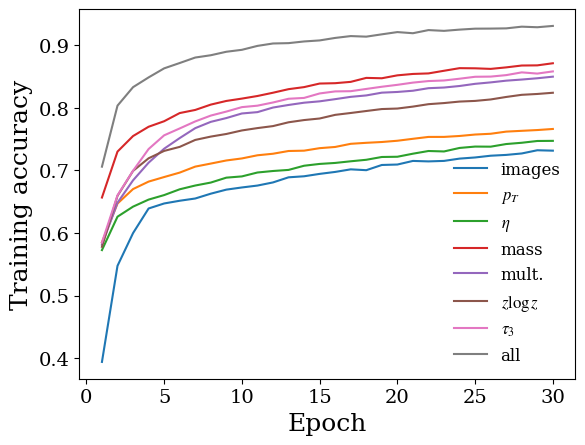

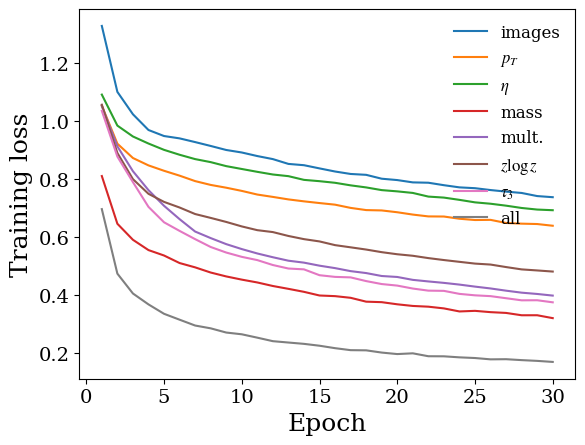

In [ ]:
plt.figure()
plt.plot(np.arange(1, np.size(history_images.history['accuracy']) + 1, 1), 
         history_images.history['accuracy'], label = 'images')

plt.plot(np.arange(1, np.size(history_pt.history['accuracy']) + 1, 1), 
         history_pt.history['accuracy'], label = r'$p_T$')

plt.plot(np.arange(1, np.size(history_eta.history['accuracy']) + 1, 1), 
         history_eta.history['accuracy'],label = r'$\eta$')

plt.plot(np.arange(1, np.size(history_mass.history['accuracy']) + 1, 1), 
         history_mass.history['accuracy'], label = 'mass')

plt.plot(np.arange(1, np.size(history_mult.history['accuracy']) + 1, 1), 
         history_mult.history['accuracy'], label = 'mult.')

plt.plot(np.arange(1, np.size(history_z.history['accuracy']) + 1, 1), 
         history_z.history['accuracy'], label = r'$z\log z$')

plt.plot(np.arange(1, np.size(history_tau3_b1.history['accuracy']) + 1, 1), 
         history_tau3_b1.history['accuracy'], label = r'$\tau_3$')

plt.plot(np.arange(1, np.size(history_images_6features.history['accuracy']) + 1, 1), 
         history_images_6features.history['accuracy'], label = 'all')

plt.ylabel('Training accuracy')
plt.xlabel('Epoch')
plt.legend(frameon = False)

plt.figure()
plt.plot(np.arange(1, np.size(history_images.history['loss']) + 1, 1), 
         history_images.history['loss'], label = 'images')

plt.plot(np.arange(1, np.size(history_pt.history['loss']) + 1, 1), 
         history_pt.history['loss'], label = '$p_T$')

plt.plot(np.arange(1, np.size(history_eta.history['loss']) + 1, 1), 
         history_eta.history['loss'],label = '$\eta$')

plt.plot(np.arange(1, np.size(history_mass.history['loss']) + 1, 1), 
         history_mass.history['loss'], label = 'mass')

plt.plot(np.arange(1, np.size(history_mult.history['loss']) + 1, 1), 
         history_mult.history['loss'], label = 'mult.')

plt.plot(np.arange(1, np.size(history_z.history['loss']) + 1, 1), 
         history_z.history['loss'], label = '$z\log z$')

plt.plot(np.arange(1, np.size(history_tau3_b1.history['loss']) + 1, 1), 
         history_tau3_b1.history['loss'], label = r'$\tau_3$')

plt.plot(np.arange(1, np.size(history_images_6features.history['loss']) + 1, 1), 
         history_images_6features.history['loss'], label = 'all')

plt.ylabel('Training loss')
plt.xlabel('Epoch')
plt.legend(loc = 'best', frameon = False)

The comparison shows that augmenting the image-based model with scalar features consistently improves training accuracy relative to the image-only baseline, indicating that the additional observables provide useful complementary information. Among the single-feature models, mass appears to yield the strongest improvement, while the full model combining all six features achieves the highest accuracy at every epoch by a clear margin.

## 5. Extension 1: Extend your machine learning classifier to take in the three jet images (jetImage, jetImageECAL, jetImageHCAL)

In this extension, the jet image representation is enriched by adding the corresponding ECAL and HCAL calorimeter images, so that the classifier can learn not only from the overall jet shape but also from how the energy is deposited in the electromagnetic and hadronic calorimeters.

In [371]:
def get_ecal(filename):
    '''Function to extract data from h5 file
    input: 
    filename: string, file path
    
    returns:
    normalised arrays of gluon, quark, w, z and top 100x100 ecal images'''
    
    #Opening the h5 file

    #The name of the file we are looking at
    file = filename
    
    #Opening the file with h5  
    df = h5py.File(file,'r')
    
    #Getting labels for each column
    labels = [label.decode('utf-8') for label in df['jetFeatureNames'][:] ]
    
    #Looking at the jet image column
    pJet = pd.DataFrame(np.array(df['jets']), columns = labels)
    
    #Only getting image data for each image when the particle type column is 1, e.g. when 'quark' column is
    # 1, that entire row is a quark type data, so add the image under column 'jets' to quark data
    data_g = pJet.drop(pJet[pJet.j_g ==0].index)
    data_q = pJet.drop(pJet[pJet.j_q ==0].index)
    data_w = pJet.drop(pJet[pJet.j_w ==0].index)
    data_z = pJet.drop(pJet[pJet.j_z ==0].index)
    data_t = pJet.drop(pJet[pJet.j_t ==0].index)
    
    #Turn the image into a numpy array
    gluon_img = df['jetImageECAL'][:] * np.array(pJet['j_g'])[:, None, None]
    quark_img = df['jetImageECAL'][:] * np.array(pJet['j_q'])[:, None, None]
    w_img = df['jetImageECAL'][:] * np.array(pJet['j_w'])[:, None, None]
    z_img = df['jetImageECAL'][:] * np.array(pJet['j_z'])[:, None, None]
    top_img = df['jetImageECAL'][:] * np.array(pJet['j_t'])[:, None, None]
    
    #The arrays are same size and most images are blank, because each array is size 10,000 where for example,
    # if the image is a gluon, that corresponding row in quark image will be an array of 0's, so remove
    # all blank images and sum of each of the 5 resulting arrays will be 10,000. There's an approximately
    # 20% split of images in each category
    gluon_img = gluon_img[np.where(np.sum(gluon_img, axis=(1, 2)) != 0)[0]]
    quark_img = quark_img[np.where(np.sum(quark_img, axis=(1, 2)) != 0)[0]]
    w_img = w_img[np.where(np.sum(w_img, axis=(1, 2)) != 0)[0]]
    z_img = z_img[np.where(np.sum(z_img, axis=(1, 2)) != 0)[0]]
    top_img = top_img[np.where(np.sum(top_img, axis=(1, 2)) != 0)[0]]
    
    #Normalise all images
    for i in range(len(gluon_img)):
        gluon_img[i] = gluon_img[i] / np.max(gluon_img)
    for i in range(len(quark_img)):
        quark_img[i] = quark_img[i] / np.max(quark_img)
    for i in range(len(w_img)):
        w_img[i] = w_img[i] / np.max(w_img)
    for i in range(len(z_img)):
        z_img[i] = z_img[i] / np.max(z_img)
    for i in range(len(top_img)):
        top_img[i] = top_img[i] / np.max(top_img)
    
    return gluon_img, quark_img, w_img, z_img, top_img

In [372]:
def get_hcal(filename):
    '''Function to extract data from h5 file 
    input: 
    filename: string, file path
    
    returns:
    normalised arrays of gluon, quark, w, z and top 100x100 hcal images'''
    
    #Opening the h5 file
    file = filename

    #Opening the file with h5  
    df = h5py.File(file,'r')
    
    #Getting labels for each column
    labels = [label.decode('utf-8') for label in df['jetFeatureNames'][:] ]
    
    #Looking at the jet image column
    pJet = pd.DataFrame(np.array(df['jets']), columns = labels)
    
    #Only getting image data for each image when the particle type column is 1, e.g. when 'quark' column is
    # 1, that entire row is a quark type data, so add the image under column 'jets' to quark data
    data_g = pJet.drop(pJet[pJet.j_g ==0].index)
    data_q = pJet.drop(pJet[pJet.j_q ==0].index)
    data_w = pJet.drop(pJet[pJet.j_w ==0].index)
    data_z = pJet.drop(pJet[pJet.j_z ==0].index)
    data_t = pJet.drop(pJet[pJet.j_t ==0].index)
    
    #Turn the image into a numpy array
    gluon_img = df['jetImageHCAL'][:] * np.array(pJet['j_g'])[:, None, None]
    quark_img = df['jetImageHCAL'][:] * np.array(pJet['j_q'])[:, None, None]
    w_img = df['jetImageHCAL'][:] * np.array(pJet['j_w'])[:, None, None]
    z_img = df['jetImageHCAL'][:] * np.array(pJet['j_z'])[:, None, None]
    top_img = df['jetImageHCAL'][:] * np.array(pJet['j_t'])[:, None, None]
    
    #The arrays are same size and most images are blank, because each array is size 10,000 where for example,
    # if the image is a gluon, that corresponding row in quark image will be an array of 0's, so remove
    # all blank images and sum of each of the 5 resulting arrays will be 10,000. There's an approximately
    # 20% split of images in each category
    gluon_img = gluon_img[np.where(np.sum(gluon_img, axis=(1, 2)) != 0)[0]]
    quark_img = quark_img[np.where(np.sum(quark_img, axis=(1, 2)) != 0)[0]]
    w_img = w_img[np.where(np.sum(w_img, axis=(1, 2)) != 0)[0]]
    z_img = z_img[np.where(np.sum(z_img, axis=(1, 2)) != 0)[0]]
    top_img = top_img[np.where(np.sum(top_img, axis=(1, 2)) != 0)[0]]
    
    #Normalise all images
    for i in range(len(gluon_img)):
        gluon_img[i] = gluon_img[i] / np.max(gluon_img)
    for i in range(len(quark_img)):
        quark_img[i] = quark_img[i] / np.max(quark_img)
    for i in range(len(w_img)):
        w_img[i] = w_img[i] / np.max(w_img)
    for i in range(len(z_img)):
        z_img[i] = z_img[i] / np.max(z_img)
    for i in range(len(top_img)):
        top_img[i] = top_img[i] / np.max(top_img)
    
    return gluon_img, quark_img, w_img, z_img, top_img

In [373]:
gluon_ecal_1, quark_ecal_1, w_ecal_1, z_ecal_1, top_ecal_1 = get_ecal('data/train/jetImage_1_100p_10000_20000.h5')
gluon_hcal_1, quark_hcal_1, w_hcal_1, z_hcal_1, top_hcal_1 = get_hcal('data/train/jetImage_1_100p_10000_20000.h5')

gluon_ecal_2, quark_ecal_2, w_ecal_2, z_ecal_2, top_ecal_2 = get_ecal('data/train/jetImage_1_100p_20000_30000.h5')
gluon_hcal_2, quark_hcal_2, w_hcal_2, z_hcal_2, top_hcal_2 = get_hcal('data/train/jetImage_1_100p_20000_30000.h5')

gluon_ecal_3, quark_ecal_3, w_ecal_3, z_ecal_3, top_ecal_3 = get_ecal('data/train/jetImage_1_100p_30000_40000.h5')
gluon_hcal_3, quark_hcal_3, w_hcal_3, z_hcal_3, top_hcal_3 = get_hcal('data/train/jetImage_1_100p_30000_40000.h5')

gluon_ecal_4, quark_ecal_4, w_ecal_4, z_ecal_4, top_ecal_4 = get_ecal('data/train/jetImage_1_100p_40000_50000.h5')
gluon_hcal_4, quark_hcal_4, w_hcal_4, z_hcal_4, top_hcal_4 = get_hcal('data/train/jetImage_1_100p_40000_50000.h5')

gluon_ecal_5, quark_ecal_5, w_ecal_5, z_ecal_5, top_ecal_5 = get_ecal('data/train/jetImage_1_100p_50000_60000.h5')
gluon_hcal_5, quark_hcal_5, w_hcal_5, z_hcal_5, top_hcal_5 = get_hcal('data/train/jetImage_1_100p_50000_60000.h5')

gluon_ecal_6, quark_ecal_6, w_ecal_6, z_ecal_6, top_ecal_6 = get_ecal('data/train/jetImage_1_100p_60000_70000.h5')
gluon_hcal_6, quark_hcal_6, w_hcal_6, z_hcal_6, top_hcal_6 = get_hcal('data/train/jetImage_1_100p_60000_70000.h5')

gluon_ecal_7, quark_ecal_7, w_ecal_7, z_ecal_7, top_ecal_7 = get_ecal('data/train/jetImage_1_100p_70000_80000.h5')
gluon_hcal_7, quark_hcal_7, w_hcal_7, z_hcal_7, top_hcal_7 = get_hcal('data/train/jetImage_1_100p_70000_80000.h5')

gluon_ecal_8, quark_ecal_8, w_ecal_8, z_ecal_8, top_ecal_8 = get_ecal('data/train/jetImage_1_100p_80000_90000.h5')
gluon_hcal_8, quark_hcal_8, w_hcal_8, z_hcal_8, top_hcal_8 = get_hcal('data/train/jetImage_1_100p_80000_90000.h5')

In [374]:
gluon_ecal = np.concatenate([gluon_ecal_1, gluon_ecal_2, gluon_ecal_3, gluon_ecal_4, gluon_ecal_5, 
                            gluon_ecal_6, gluon_ecal_7, gluon_ecal_7])

quark_ecal = np.concatenate([quark_ecal_1, quark_ecal_2, quark_ecal_3, quark_ecal_4, 
                            quark_ecal_5, quark_ecal_6, quark_ecal_7, quark_ecal_7])

w_ecal = np.concatenate([w_ecal_1, w_ecal_2, w_ecal_3, w_ecal_4,
                        w_ecal_5, w_ecal_6, w_ecal_7, w_ecal_8])

z_ecal = np.concatenate([z_ecal_1, z_ecal_2, z_ecal_3, z_ecal_4,
                        z_ecal_5, z_ecal_6, z_ecal_7, z_ecal_7])

top_ecal = np.concatenate([top_ecal_1, top_ecal_2, top_ecal_3, top_ecal_4,
                          top_ecal_5, top_ecal_6, top_ecal_7, top_ecal_7])

In [375]:
gluon_hcal = np.concatenate([gluon_hcal_1, gluon_hcal_2, gluon_hcal_3, gluon_hcal_4, gluon_hcal_5, 
                            gluon_hcal_6, gluon_hcal_7, gluon_hcal_8])

quark_hcal = np.concatenate([quark_hcal_1, quark_hcal_2, quark_hcal_3, quark_hcal_4, 
                            quark_hcal_5, quark_hcal_6, quark_hcal_7, quark_hcal_8])

w_hcal = np.concatenate([w_hcal_1, w_hcal_2, w_hcal_3, w_hcal_4,
                        w_hcal_5, w_hcal_6, w_hcal_7, w_hcal_8])

z_hcal = np.concatenate([z_hcal_1, z_hcal_2, z_hcal_3, z_hcal_4,
                        z_hcal_5, z_hcal_6, z_hcal_7, z_hcal_8])

top_hcal = np.concatenate([top_hcal_1, top_hcal_2, top_hcal_3, top_hcal_4,
                          top_hcal_5, top_hcal_6, top_hcal_7, top_hcal_8])

In [376]:
ecal = np.concatenate([gluon_ecal, quark_ecal, w_ecal, z_ecal, top_ecal])

hcal = np.concatenate([gluon_hcal, quark_hcal, w_hcal, z_hcal, top_hcal])

In [377]:
hcal = crop_images_center(hcal)

# Reshape for CNN input

hcal = hcal.reshape(-1, 40, 40, 1)
hcal_train, hcal_temp = train_test_split(hcal, test_size = 0.3, random_state = 69)

hcal_val, hcal_test = train_test_split(hcal_temp, test_size = 0.5, random_state = 69)

Many of the ECAL images are blank, likely because not all jet classes produce a strong electromagnetic energy deposition in the calorimeter; in addition, particles such as gluons and Z bosons may yield weaker electromagnetic signatures, resulting in sparse or empty ECAL representations. To address the resulting imbalance between classes, I apply a data expansion procedure in which images are randomly duplicated within each category so that all particle classes have equal sample sizes and my model is unbiased. 

In [ ]:
def expand_dataset_with_copies(original_array, desired_size):
    '''Function to resize image array'''
    current_size = original_array.shape[0]
    if current_size >= desired_size:
        return original_array

    additional_needed = desired_size - current_size
    indices_to_duplicate = np.random.choice(current_size, additional_needed, replace=True)
    duplicated_portion = original_array[indices_to_duplicate]
    enlarged_array = np.concatenate([original_array, duplicated_portion], axis=0)
    
    return enlarged_array

In [ ]:
gluon_ecal = expand_dataset_with_copies(gluon_ecal, 15954)
quark_ecal = expand_dataset_with_copies(quark_ecal, 15617)
w_ecal = expand_dataset_with_copies(w_ecal, 16195)
z_ecal = expand_dataset_with_copies(z_ecal, 16246)
top_ecal = expand_dataset_with_copies(top_ecal, 15988)

ecal = np.concatenate([gluon_ecal, quark_ecal, w_ecal, z_ecal, top_ecal])

In [380]:
ecal = crop_images_center(ecal)


ecal = ecal.reshape(-1, 40, 40, 1)
ecal_train, ecal_temp = train_test_split(ecal, test_size = 0.3, random_state = 69)

ecal_val, ecal_test = train_test_split(ecal_temp, test_size = 0.5, random_state = 69)

### 5.2 Training

In [381]:
image_input = Input(shape=(40, 40, 1), name = 'jet_image_input')

x_image = Conv2D(32, (3, 3), activation='relu')(image_input)
    
x_image = MaxPooling2D((2, 2))(x_image)
    
x_image = Conv2D(64, (3, 3), activation = 'relu')(x_image)
    
x_image = MaxPooling2D((2, 2))(x_image)
    
x_image = Conv2D(64, (3, 3), activation = 'relu')(x_image)
    
x_image = MaxPooling2D((2, 2))(x_image)
    
x_image = Dropout(0.25)(x_image)
    
x_image = Flatten()(x_image)

hcal_input = Input(shape = (40, 40, 1), name = 'hcal_input')

y_image = Conv2D(32, (3, 3), activation='relu')(hcal_input)
    
y_image = MaxPooling2D((2, 2))(y_image)
    
y_image = Conv2D(64, (3, 3), activation = 'relu')(y_image)
    
y_image = MaxPooling2D((2, 2))(y_image)
    
y_image = Conv2D(64, (3, 3), activation = 'relu')(y_image)
    
y_image = MaxPooling2D((2, 2))(y_image)
    
y_image = Dropout(0.25)(y_image)
    
y_image = Flatten()(y_image)

ecal_input = Input(shape = (40, 40, 1), name = 'ecal_input')

z_image = Conv2D(32, (3, 3), activation='relu')(ecal_input)
   
z_image = MaxPooling2D((2, 2))(z_image)
    
z_image = Conv2D(64, (3, 3), activation = 'relu')(z_image)
    
z_image = MaxPooling2D((2, 2))(z_image)
    
z_image = Conv2D(64, (3, 3), activation = 'relu')(z_image)
    
z_image = MaxPooling2D((2, 2))(z_image)
    
z_image = Dropout(0.25)(z_image)
    
z_image = Flatten()(z_image)
    
concatenated = concatenate([x_image, y_image, z_image])

x_combined = Dense(256, activation = 'relu')(concatenated)

x_combined = Dense(256, activation = 'sigmoid')(concatenated)
    
x_combined = Dense(128, activation = 'sigmoid')(x_combined)

x_combined = Dense(128, activation = 'relu')(concatenated)
    
x_combined = Dense(64, activation = 'relu')(x_combined)

x_combined = Dense(64, activation = 'sigmoid')(x_combined)
    
x_combined = Dense(5, activation = 'softmax')(x_combined)  # Assuming 5 classes

model_cal = Model(inputs = [image_input, hcal_input, ecal_input], outputs = x_combined)
    
model_cal.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    
model_cal.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ jet_image_input     │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hcal_input          │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ecal_input          │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_111 (Conv2D) │ (None, 38, 38,    │        320 │ jet_image_input[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_114 (Conv2D) │ (None, 38, 38,    │        320 │ hcal_input[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_117 (Conv2D) │ (None, 38, 38,    │        320 │ ecal_input[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_111   │ (None, 19, 19,    │          0 │ conv2d_111[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_114   │ (None, 19, 19,    │          0 │ conv2d_114[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_117   │ (None, 19, 19,    │          0 │ conv2d_117[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_112 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_115 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_118 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_11… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_112   │ (None, 8, 8, 64)  │          0 │ conv2d_112[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_115   │ (None, 8, 8, 64)  │          0 │ conv2d_115[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_118   │ (None, 8, 8, 64)  │          0 │ conv2d_118[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_113 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_116 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_11… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 401,285 (1.53 MB)

 Trainable params: 401,285 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cal = model_cal.fit([images_train, hcal_train, ecal_train], labels_train_onehot, epochs=epochs_number,
                    validation_data=([images_val, hcal_val, ecal_val], labels_val_onehot), verbose=1)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 51s 28ms/step - accuracy: 0.5771 - loss: 1.0680 - val_accuracy: 0.6582 - val_loss: 0.9098
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.6533 - loss: 0.9064 - val_accuracy: 0.6745 - val_loss: 0.8556
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 51s 29ms/step - accuracy: 0.6859 - loss: 0.8320 - val_accuracy: 0.7091 - val_loss: 0.7821
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 47s 27ms/step - accuracy: 0.7107 - loss: 0.7734 - val_accuracy: 0.7289 - val_loss: 0.7329
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.7308 - loss: 0.7213 - val_accuracy: 0.7533 - val_loss: 0.6719
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 51s 29ms/step - accuracy: 0.7523 - loss: 0.6687 - val_accuracy: 0.7720 - val_loss: 0.6233
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 55s 31ms/step - accuracy: 0.7720 - loss: 0.6199 - val_accuracy: 0.7944 - val_loss: 0.5774
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 51s 29ms/step - accuracy: 0.7851 -

The final accuracy was 0.9197 and the final loss was 0.2240


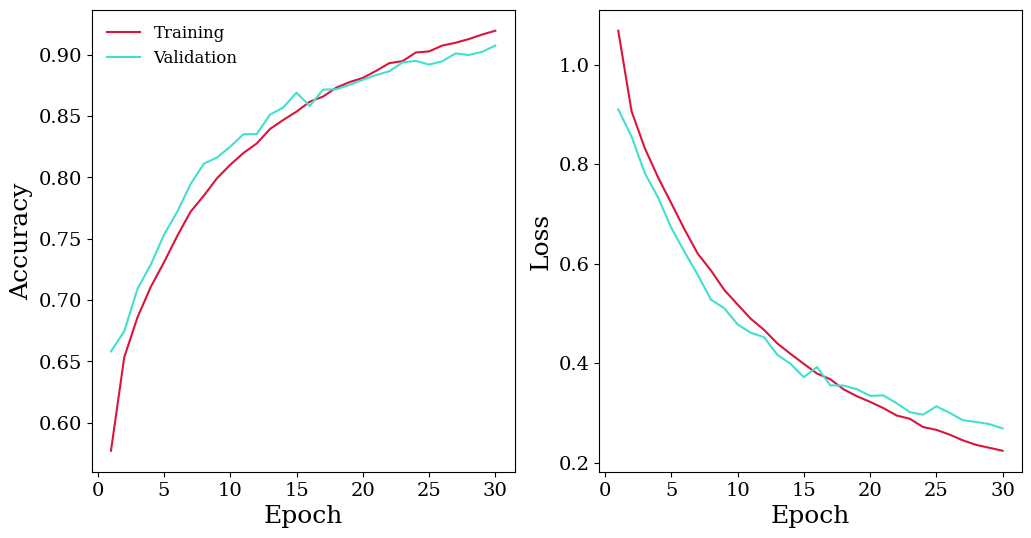

In [383]:
loss_acc(history_cal, 'CAL')

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy for Gluon: 87.91%
Accuracy for Quark: 94.17%
Accuracy for W: 90.69%
Accuracy for Z: 91.06%
Accuracy for T: 85.98%


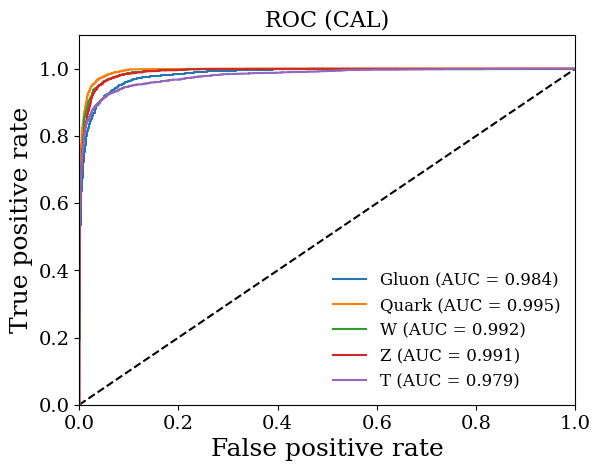

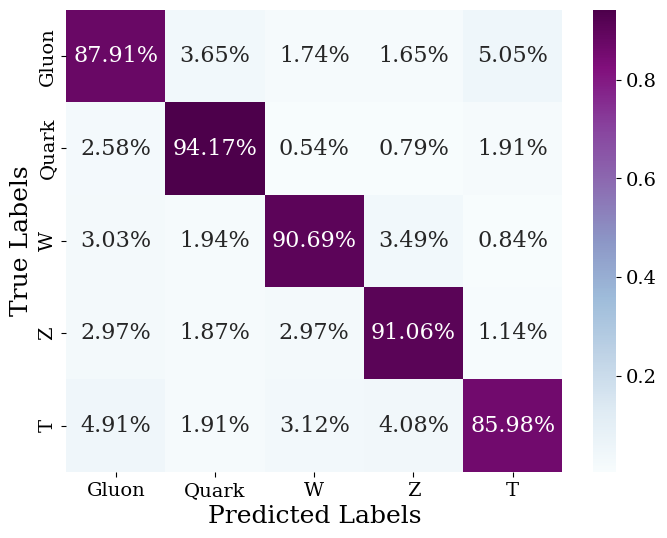

In [ ]:
probabilities_cal = model_cal.predict([images_test, hcal_test, ecal_test])
roc_cal = ROC(probabilities_cal, 'CAL')
cal_pred_labels, cal_acc = confusion_matrix(probabilities_cal, 'CAL')

## 6. Extension 2: Compare your machine learning classifier to one that just uses the jet features (no image input)

In the previous analysis (section 4) six jet features were examined separately to assess their individual contribution to the classification task, whereas in this section, I extract a wider set of jet observables and increase the number of scalar inputs from 6 to 16, allowing the construction of a model that relies exclusively on jet features rather than jet images. \
This provides a useful benchmark for evaluating how strongly the classification performance depends on image information, and whether a purely scalar representation of the jets can already capture most of the relevant physics for separating the five particle classes.

In [385]:
#Incorportaing some additional features 

tau3_b1 = np.concatenate([concatenated_features['j_tau3_b1']['g'], concatenated_features['j_tau3_b1']['q'],
                    concatenated_features['j_tau3_b1']['w'], concatenated_features['j_tau3_b1']['z'],
                    concatenated_features['j_tau3_b1']['t']])

d2_b2 = np.concatenate([concatenated_features['j_d2_b2']['g'], concatenated_features['j_d2_b2']['q'],
                    concatenated_features['j_d2_b2']['w'], concatenated_features['j_d2_b2']['z'],
                    concatenated_features['j_d2_b2']['t']])

d2_a1_b2 = np.concatenate([concatenated_features['j_d2_a1_b2']['g'], concatenated_features['j_d2_a1_b2']['q'],
                    concatenated_features['j_d2_a1_b2']['w'], concatenated_features['j_d2_a1_b2']['z'],
                    concatenated_features['j_d2_a1_b2']['t']])

n2_b2 = np.concatenate([concatenated_features['j_n2_b2']['g'], concatenated_features['j_n2_b2']['q'],
                    concatenated_features['j_n2_b2']['w'], concatenated_features['j_n2_b2']['z'],
                    concatenated_features['j_n2_b2']['t']])

n2_b1 = np.concatenate([concatenated_features['j_n2_b1_mmdt']['g'], concatenated_features['j_n2_b1_mmdt']['q'],
                    concatenated_features['j_n2_b1_mmdt']['w'], concatenated_features['j_n2_b1_mmdt']['z'],
                    concatenated_features['j_n2_b1_mmdt']['t']])

tau32_b1 = np.concatenate([concatenated_features['j_tau32_b1_mmdt']['g'], 
                concatenated_features['j_tau32_b1_mmdt']['q'], concatenated_features['j_tau32_b1_mmdt']['w'], 
                concatenated_features['j_tau32_b1_mmdt']['z'], concatenated_features['j_tau32_b1_mmdt']['t']])

c1_b1_mmdt = np.concatenate([concatenated_features['j_c1_b1_mmdt']['g'], 
                             concatenated_features['j_c1_b1_mmdt']['q'],
                    concatenated_features['j_c1_b1_mmdt']['w'], 
                             concatenated_features['j_c1_b1_mmdt']['z'],
                    concatenated_features['j_c1_b1_mmdt']['t']])

c2_b1_mmdt = np.concatenate([concatenated_features['j_c2_b1_mmdt']['g'], 
                             concatenated_features['j_c2_b1_mmdt']['q'],
                    concatenated_features['j_c2_b1_mmdt']['w'], 
                             concatenated_features['j_c2_b1_mmdt']['z'],
                    concatenated_features['j_c2_b1_mmdt']['t']])

mass_trim = np.concatenate([concatenated_features['j_mass_trim']['g'], 
                            concatenated_features['j_mass_trim']['q'],
                    concatenated_features['j_mass_trim']['w'], concatenated_features['j_mass_trim']['z'],
                    concatenated_features['j_mass_trim']['t']])

mass_mmdt = np.concatenate([concatenated_features['j_mass_mmdt']['g'], 
                            concatenated_features['j_mass_mmdt']['q'],
                    concatenated_features['j_mass_mmdt']['w'], concatenated_features['j_mass_mmdt']['z'],
                    concatenated_features['j_mass_mmdt']['t']])

mass_sdb2 = np.concatenate([concatenated_features['j_mass_sdb2']['g'], 
                            concatenated_features['j_mass_sdb2']['q'],
                    concatenated_features['j_mass_sdb2']['w'], concatenated_features['j_mass_sdb2']['z'],
                    concatenated_features['j_mass_sdb2']['t']])
def split_features(features_dict):
    '''
    Function to
    input:
    features_dict: dictionary of additioanl features
    returns:
    train-test splitted features 
    '''  
    split_results = {}
    
    for feature_name, data in features_dict.items():
        train, temp = train_test_split(data, test_size = 0.3, random_state = 69)
        val, test = train_test_split(temp, test_size = 0.5, random_state = 69)
        split_results[feature_name] = {'train': train, 'val': val, 'test': test}
    
    return split_results

all_features = {
    'tau3_b1': tau3_b1,
    'd2_b2': d2_b2,
    'd2_a1_b2': d2_a1_b2,
    'n2_b2': n2_b2,
    'n2_b1': n2_b1,
    'tau32_b1': tau32_b1,
    'c1_b1_mmdt': c1_b1_mmdt,
    'c2_b1_mmdt': c2_b1_mmdt,
    'mass_trim': mass_trim,
    'mass_mmdt': mass_mmdt,
    'mass_sdb2': mass_sdb2
}

split_data = split_features(all_features)

In [387]:
pt_input = Input(shape=(1,), name='pt_input')
x_pt = Dense(128, activation='relu')(pt_input)
x_pt = Dense(64, activation='relu')(x_pt)

eta_input = Input(shape=(1,), name='eta_input')
x_eta = Dense(128, activation='relu')(eta_input)
x_eta = Dense(64, activation='relu')(x_eta)

mass_input = Input(shape=(1,), name='mass_input')
x_mass = Dense(128, activation='relu')(mass_input)
x_mass = Dense(64, activation='relu')(x_mass)

mult_input = Input(shape=(1,), name='mult_input')
x_mult = Dense(128, activation='relu')(mult_input)
x_mult = Dense(64, activation='relu')(x_mult)

z_input = Input(shape=(1,), name='zlogz_input')
x_z = Dense(128, activation='relu')(z_input)
x_z = Dense(64, activation='relu')(x_z)

tau3_b1_input = Input(shape=(1,), name='tau3_b1_input')
x_tau3_b1 = Dense(128, activation='relu')(tau3_b1_input)
x_tau3_b1 = Dense(64, activation='relu')(x_tau3_b1)

# Adding more scalar features
d2_b2_input = Input(shape=(1,), name='d2_b2_input')
x_d2_b2 = Dense(128, activation='relu')(d2_b2_input)
x_d2_b2 = Dense(64, activation='relu')(x_d2_b2)

d2_a1_b2_input = Input(shape=(1,), name='d2_a1_b2_input')
x_d2_a1_b2 = Dense(128, activation='relu')(d2_a1_b2_input)
x_d2_a1_b2 = Dense(64, activation='relu')(x_d2_a1_b2)

n2_b2_input = Input(shape=(1,), name='n2_b2_input')
x_n2_b2 = Dense(128, activation='relu')(n2_b2_input)
x_n2_b2 = Dense(64, activation='relu')(x_n2_b2)

n2_b1_input = Input(shape=(1,), name='n2_b1_input')
x_n2_b1 = Dense(128, activation='relu')(n2_b1_input)
x_n2_b1 = Dense(64, activation='relu')(x_n2_b1)

tau32_b1_input = Input(shape=(1,), name='tau32_b1_input')
x_tau32_b1 = Dense(128, activation='relu')(tau32_b1_input)
x_tau32_b1 = Dense(64, activation='relu')(x_tau32_b1)

c1_b1_input = Input(shape=(1,), name='c1_b1_input')
x_c1_b1 = Dense(128, activation='relu')(c1_b1_input)
x_c1_b1 = Dense(64, activation='relu')(x_c1_b1)

c2_b1_input = Input(shape=(1,), name='c2_b1_input')
x_c2_b1 = Dense(128, activation='relu')(c2_b1_input)
x_c2_b1 = Dense(64, activation='relu')(x_c2_b1)

mass_trim_input = Input(shape=(1,), name='mass_trim_input')
x_mass_trim = Dense(128, activation='relu')(mass_trim_input)
x_mass_trim = Dense(64, activation='relu')(x_mass_trim)

mass_mmdt_input = Input(shape=(1,), name='mass_mmdt_input')
x_mass_mmdt = Dense(128, activation='relu')(mass_mmdt_input)
x_mass_mmdt = Dense(64, activation='relu')(x_mass_mmdt)

mass_sdb2_input = Input(shape=(1,), name='mass_sdb2_input')
x_mass_sdb2 = Dense(128, activation='relu')(mass_sdb2_input)
x_mass_sdb2 = Dense(64, activation='relu')(x_mass_sdb2)

concatenated = concatenate([x_pt, x_eta, x_mass, x_mult, x_z,
    x_tau3_b1, x_d2_b2, x_d2_a1_b2, x_n2_b2, x_n2_b1, x_tau32_b1,
    x_c1_b1, x_c2_b1, x_mass_trim, x_mass_mmdt, x_mass_sdb2
])

x_combined = Dense(256, activation='relu')(concatenated)
x_combined = Dense(256, activation='sigmoid')(concatenated)
x_combined = Dense(128, activation='sigmoid')(x_combined)
x_combined = Dense(128, activation='relu')(x_combined)
x_combined = Dense(64, activation='sigmoid')(x_combined)
x_combined = Dense(64, activation='relu')(x_combined)
x_combined = Dense(5, activation='softmax')(x_combined)

model_features = Model(
    inputs=[pt_input, eta_input, mass_input, mult_input, z_input,
        tau3_b1_input, d2_b2_input, d2_a1_b2_input, n2_b2_input, n2_b1_input, tau32_b1_input,
        c1_b1_input, c2_b1_input, mass_trim_input, mass_mmdt_input, mass_sdb2_input
    ],
    outputs=x_combined
)

model_features.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_features.summary()

Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ pt_input            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mult_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zlogz_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tau3_b1_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2_b2_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2_a1_b2_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n2_b2_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n2_b1_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tau32_b1_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c1_b1_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ c2_b1_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_trim_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_mmdt_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_sdb2_input     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_484 (Dense)   │ (None, 128)       │        256 │ pt_input[0][0]  

 Total params: 460,741 (1.76 MB)

 Trainable params: 460,741 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_features = model_features.fit(
    [pt_train, eta_train, mass_train, mult_train, z_train, 
     split_data['tau3_b1']['train'], split_data['d2_b2']['train'], split_data['d2_a1_b2']['train'], 
     split_data['n2_b2']['train'], split_data['n2_b1']['train'], split_data['tau32_b1']['train'],
     split_data['c1_b1_mmdt']['train'], split_data['c2_b1_mmdt']['train'], split_data['mass_trim']['train'],
     split_data['mass_mmdt']['train'], split_data['mass_sdb2']['train']], 
    labels_train_onehot, 
    epochs=epochs_number,
    validation_data=(
        [pt_val, eta_val, mass_val, mult_val, z_val, 
         split_data['tau3_b1']['val'], split_data['d2_b2']['val'], split_data['d2_a1_b2']['val'], 
         split_data['n2_b2']['val'], split_data['n2_b1']['val'], split_data['tau32_b1']['val'],
         split_data['c1_b1_mmdt']['val'], split_data['c2_b1_mmdt']['val'], split_data['mass_trim']['val'],
         split_data['mass_mmdt']['val'], split_data['mass_sdb2']['val']], 
        labels_val_onehot),
    verbose=1
)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6570 - loss: 0.6719 - val_accuracy: 0.7604 - val_loss: 0.4353
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7782 - loss: 0.4019 - val_accuracy: 0.8192 - val_loss: 0.3476
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8231 - loss: 0.3401 - val_accuracy: 0.8430 - val_loss: 0.3194
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8464 - loss: 0.3027 - val_accuracy: 0.8648 - val_loss: 0.2739
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8576 - loss: 0.2847 - val_accuracy: 0.8735 - val_loss: 0.2674
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8668 - loss: 0.2682 - val_accuracy: 0.8658 - val_loss: 0.2590
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8717 - loss: 0.2564 - val_accuracy: 0.8616 - val_loss: 0.2786
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8759 - loss: 0.2467 - 

The final accuracy was 0.9185 and the final loss was 0.1725


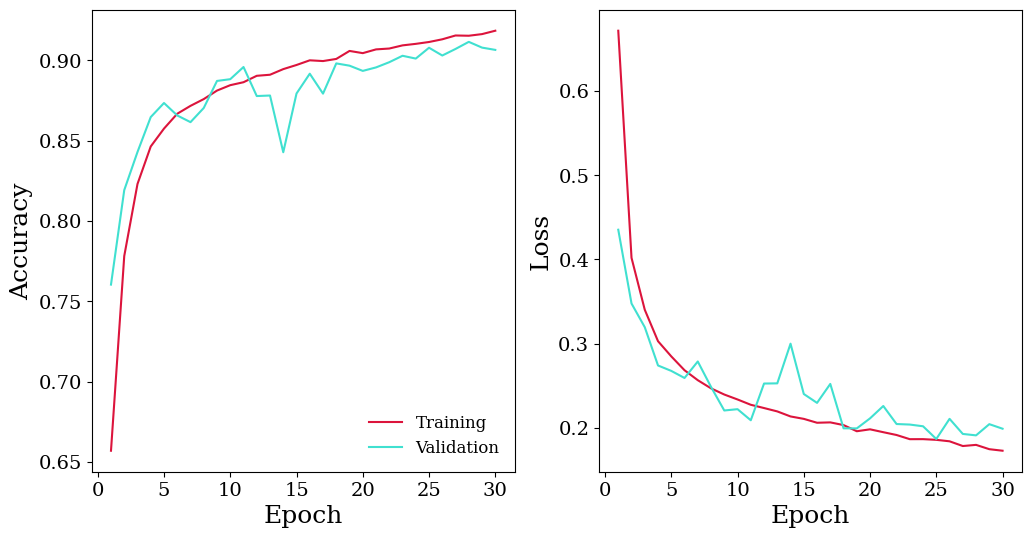

In [389]:
loss_acc(history_features, 'features')

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step
Accuracy for Gluon: 98.81%
Accuracy for Quark: 96.05%
Accuracy for W: 73.09%
Accuracy for Z: 86.02%
Accuracy for T: 99.79%


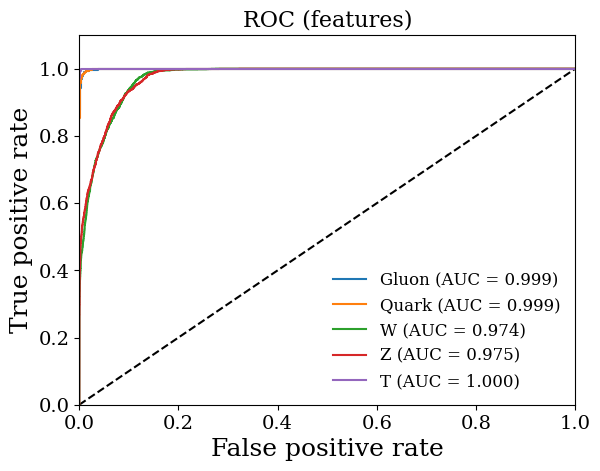

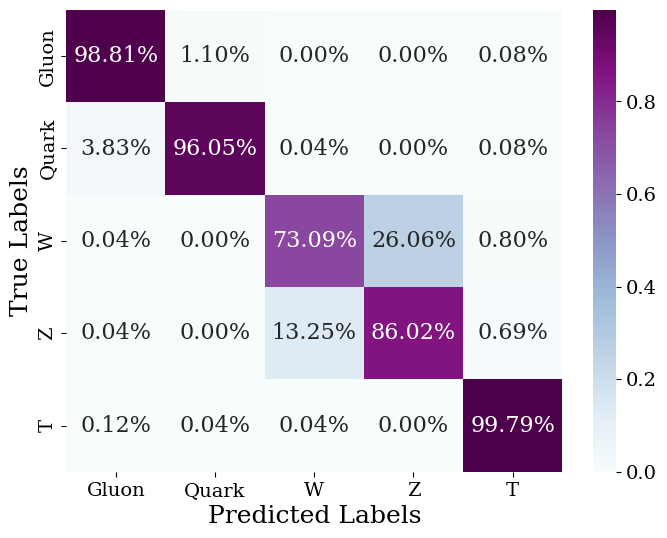

In [ ]:
probabilities_features = model_features.predict([pt_test, eta_test, mass_test, mult_test, z_test, 
         split_data['tau3_b1']['test'], split_data['d2_b2']['test'], split_data['d2_a1_b2']['test'], 
         split_data['n2_b2']['test'], split_data['n2_b1']['test'], split_data['tau32_b1']['test'],
         split_data['c1_b1_mmdt']['test'], split_data['c2_b1_mmdt']['test'], split_data['mass_trim']['test'],
         split_data['mass_mmdt']['test'], split_data['mass_sdb2']['test']])

roc_features = ROC(probabilities_features, 'features')

features_pred_labels, features_acc = confusion_matrix(probabilities_features, 'features')

## 7. Extension 3: Develop a combined classifier that takes both images and features

This extension brings together all representations used so far: jet images, calorimeter images, and scalar jet features. The goal is to evaluate whether a unified multiview architecture, combining both low-level and high-level information, can outperform the previous models and achieve the best overall jet classification accuracy.


### 7.1 Combining jet images with all features

In [ ]:
#Incorporating the jet image + 16 jet features

image_input = Input(shape=(40, 40, 1), name='image_input')
x_image = Conv2D(32, (3, 3), activation='relu')(image_input)
x_image = MaxPooling2D((2, 2))(x_image)
x_image = Conv2D(64, (3, 3), activation='relu')(x_image)
x_image = MaxPooling2D((2, 2))(x_image)
x_image = Conv2D(64, (3, 3), activation='relu')(x_image)
x_image = MaxPooling2D((2, 2))(x_image)
x_image = Dropout(0.25)(x_image)
x_image = Flatten()(x_image)

#Features
pt_input = Input(shape=(1,), name='pt_input')
x_pt = Dense(128, activation='relu')(pt_input)
x_pt = Dense(64, activation='relu')(x_pt)

eta_input = Input(shape=(1,), name='eta_input')
x_eta = Dense(128, activation='relu')(eta_input)
x_eta = Dense(64, activation='relu')(x_eta)

mass_input = Input(shape=(1,), name='mass_input')
x_mass = Dense(128, activation='relu')(mass_input)
x_mass = Dense(64, activation='relu')(x_mass)

mult_input = Input(shape=(1,), name='mult_input')
x_mult = Dense(128, activation='relu')(mult_input)
x_mult = Dense(64, activation='relu')(x_mult)

z_input = Input(shape=(1,), name='zlogz_input')
x_z = Dense(128, activation='relu')(z_input)
x_z = Dense(64, activation='relu')(x_z)

tau3_b1_input = Input(shape=(1,), name='tau3_b1_input')
x_tau3_b1 = Dense(128, activation='relu')(tau3_b1_input)
x_tau3_b1 = Dense(64, activation='relu')(x_tau3_b1)

# Adding more scalar features
d2_b2_input = Input(shape=(1,), name='d2_b2_input')
x_d2_b2 = Dense(128, activation='relu')(d2_b2_input)
x_d2_b2 = Dense(64, activation='relu')(x_d2_b2)

d2_a1_b2_input = Input(shape=(1,), name='d2_a1_b2_input')
x_d2_a1_b2 = Dense(128, activation='relu')(d2_a1_b2_input)
x_d2_a1_b2 = Dense(64, activation='relu')(x_d2_a1_b2)

n2_b2_input = Input(shape=(1,), name='n2_b2_input')
x_n2_b2 = Dense(128, activation='relu')(n2_b2_input)
x_n2_b2 = Dense(64, activation='relu')(x_n2_b2)

n2_b1_input = Input(shape=(1,), name='n2_b1_input')
x_n2_b1 = Dense(128, activation='relu')(n2_b1_input)
x_n2_b1 = Dense(64, activation='relu')(x_n2_b1)

tau32_b1_input = Input(shape=(1,), name='tau32_b1_input')
x_tau32_b1 = Dense(128, activation='relu')(tau32_b1_input)
x_tau32_b1 = Dense(64, activation='relu')(x_tau32_b1)

c1_b1_input = Input(shape=(1,), name='c1_b1_input')
x_c1_b1 = Dense(128, activation='relu')(c1_b1_input)
x_c1_b1 = Dense(64, activation='relu')(x_c1_b1)

c2_b1_input = Input(shape=(1,), name='c2_b1_input')
x_c2_b1 = Dense(128, activation='relu')(c2_b1_input)
x_c2_b1 = Dense(64, activation='relu')(x_c2_b1)

mass_trim_input = Input(shape=(1,), name='mass_trim_input')
x_mass_trim = Dense(128, activation='relu')(mass_trim_input)
x_mass_trim = Dense(64, activation='relu')(x_mass_trim)

mass_mmdt_input = Input(shape=(1,), name='mass_mmdt_input')
x_mass_mmdt = Dense(128, activation='relu')(mass_mmdt_input)
x_mass_mmdt = Dense(64, activation='relu')(x_mass_mmdt)

mass_sdb2_input = Input(shape=(1,), name='mass_sdb2_input')
x_mass_sdb2 = Dense(128, activation='relu')(mass_sdb2_input)
x_mass_sdb2 = Dense(64, activation='relu')(x_mass_sdb2)

# Concatenate
concatenated = concatenate([
    x_image, x_pt, x_eta, x_mass, x_mult, x_z,
    x_tau3_b1, x_d2_b2, x_d2_a1_b2, x_n2_b2, x_n2_b1, x_tau32_b1,
    x_c1_b1, x_c2_b1, x_mass_trim, x_mass_mmdt, x_mass_sdb2
])


x_combined = Dense(256, activation='relu')(concatenated)
x_combined = Dense(256, activation='sigmoid')(concatenated)
x_combined = Dense(128, activation='sigmoid')(x_combined)
x_combined = Dense(128, activation='relu')(x_combined)
x_combined = Dense(64, activation='sigmoid')(x_combined)
x_combined = Dense(64, activation='relu')(x_combined)
x_combined = Dense(5, activation='softmax')(x_combined)

model_images_all_features = Model(
    inputs=[
        image_input, pt_input, eta_input, mass_input, mult_input, z_input,
        tau3_b1_input, d2_b2_input, d2_a1_b2_input, n2_b2_input, n2_b1_input, tau32_b1_input,
        c1_b1_input, c2_b1_input, mass_trim_input, mass_mmdt_input, mass_sdb2_input
    ],
    outputs=x_combined
)

model_images_all_features.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_images_all_features.summary()

Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_120 (Conv2D) │ (None, 38, 38,    │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_120   │ (None, 19, 19,    │          0 │ conv2d_120[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_121 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_121   │ (None, 8, 8, 64)  │          0 │ conv2d_121[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_122 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_122   │ (None, 3, 3, 64)  │          0 │ conv2d_122[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pt_input            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ eta_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mass_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mult_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zlogz_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tau3_b1_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2_b2_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2_a1_b2_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n2_b2_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n2_b1_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 663,941 (2.53 MB)

 Trainable params: 663,941 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_images_all_features = model_images_all_features.fit(
    [images_train, pt_train, eta_train, mass_train, mult_train, z_train, 
     split_data['tau3_b1']['train'], split_data['d2_b2']['train'], split_data['d2_a1_b2']['train'], 
     split_data['n2_b2']['train'], split_data['n2_b1']['train'], split_data['tau32_b1']['train'],
     split_data['c1_b1_mmdt']['train'], split_data['c2_b1_mmdt']['train'], split_data['mass_trim']['train'],
     split_data['mass_mmdt']['train'], split_data['mass_sdb2']['train']], 
    labels_train_onehot, 
    epochs=epochs_number,
    validation_data=(
        [images_val, pt_val, eta_val, mass_val, mult_val, z_val, 
         split_data['tau3_b1']['val'], split_data['d2_b2']['val'], split_data['d2_a1_b2']['val'], 
         split_data['n2_b2']['val'], split_data['n2_b1']['val'], split_data['tau32_b1']['val'],
         split_data['c1_b1_mmdt']['val'], split_data['c2_b1_mmdt']['val'], split_data['mass_trim']['val'],
         split_data['mass_mmdt']['val'], split_data['mass_sdb2']['val']], 
        labels_val_onehot),
    verbose=1
)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9563 - loss: 0.0943 - val_accuracy: 0.9527 - val_loss: 0.1000
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9555 - loss: 0.0981 - val_accuracy: 0.9603 - val_loss: 0.0906
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9563 - loss: 0.0982 - val_accuracy: 0.9575 - val_loss: 0.0929
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9574 - loss: 0.0938 - val_accuracy: 0.9628 - val_loss: 0.0820
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9547 - loss: 0.0979 - val_accuracy: 0.9585 - val_loss: 0.0884
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.9581 - loss: 0.0926 - val_accuracy: 0.9565 - val_loss: 0.0930
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9578 - loss: 0.0915 - val_accuracy: 0.9622 - val_loss: 0.0820
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.9592 -

The final accuracy was 0.9647 and the final loss was 0.0795


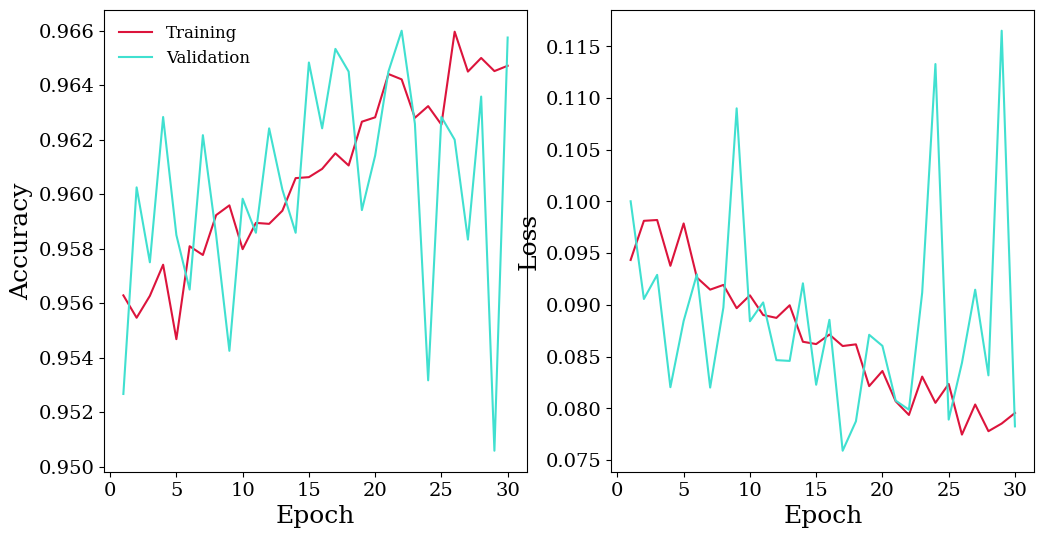

In [ ]:
loss_acc(history_images_all_features, 'aditional featuers')

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy for Gluon: 99.66%
Accuracy for Quark: 99.92%
Accuracy for W: 95.07%
Accuracy for Z: 86.23%
Accuracy for T: 99.79%


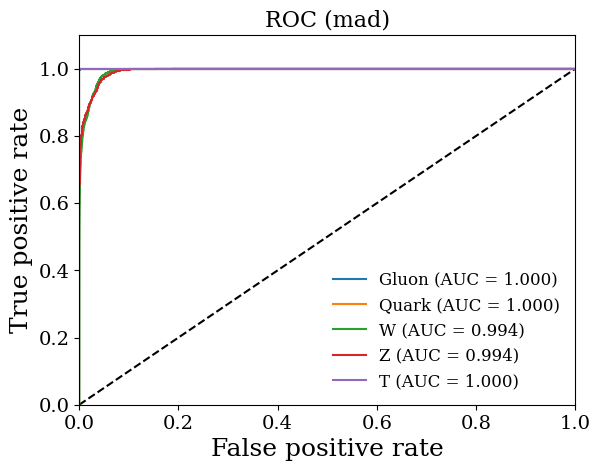

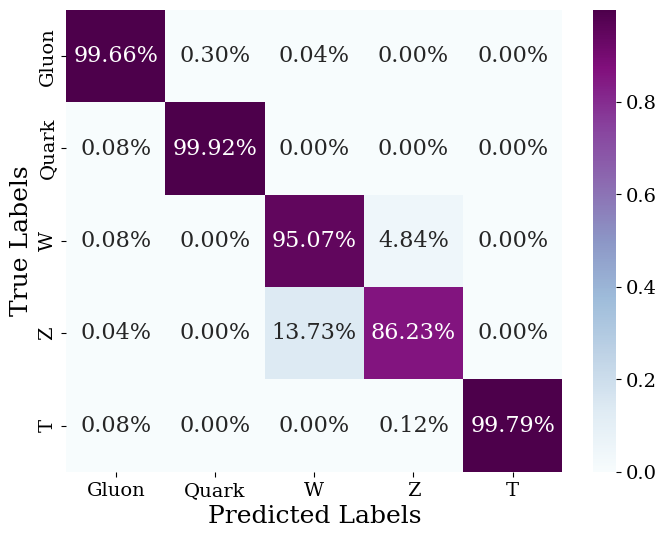

In [ ]:
probabilities_mad = model_images_all_features.predict([images_test, pt_test, eta_test, mass_test, mult_test, z_test, 
         split_data['tau3_b1']['test'], split_data['d2_b2']['test'], split_data['d2_a1_b2']['test'], 
         split_data['n2_b2']['test'], split_data['n2_b1']['test'], split_data['tau32_b1']['test'],
         split_data['c1_b1_mmdt']['test'], split_data['c2_b1_mmdt']['test'], split_data['mass_trim']['test'],
         split_data['mass_mmdt']['test'], split_data['mass_sdb2']['test']])

roc_img_features = ROC(probabilities_mad, 'mad')

mad_pred_labels, mad_acc = confusion_matrix(probabilities_mad, 'Features')

The model is highly accurate at classifying gluons, quarks and top quarks with >99% accuracy but still has some difficulty in correctly classifiying W and Z bosons.

### 7.2  Combining jet images, CAL images and all features

In [397]:
image_input = Input(shape=(40, 40, 1), name = 'jet_image_input')

x_image = Conv2D(32, (3, 3), activation='relu')(image_input)
    
x_image = MaxPooling2D((2, 2))(x_image)
    
x_image = Conv2D(64, (3, 3), activation = 'relu')(x_image)
    
x_image = MaxPooling2D((2, 2))(x_image)
    
x_image = Conv2D(64, (3, 3), activation = 'relu')(x_image)
    
x_image = MaxPooling2D((2, 2))(x_image)
    
x_image = Dropout(0.25)(x_image)
    
x_image = Flatten()(x_image)

hcal_input = Input(shape = (40, 40, 1), name = 'hcal_input')

y_image = Conv2D(32, (3, 3), activation='relu')(hcal_input)
    
y_image = MaxPooling2D((2, 2))(y_image)
    
y_image = Conv2D(64, (3, 3), activation = 'relu')(y_image)
    
y_image = MaxPooling2D((2, 2))(y_image)
    
y_image = Conv2D(64, (3, 3), activation = 'relu')(y_image)
    
y_image = MaxPooling2D((2, 2))(y_image)
    
y_image = Dropout(0.25)(y_image)
    
y_image = Flatten()(y_image)

ecal_input = Input(shape = (40, 40, 1), name = 'ecal_input')

z_image = Conv2D(32, (3, 3), activation='relu')(ecal_input)
   
z_image = MaxPooling2D((2, 2))(z_image)
    
z_image = Conv2D(64, (3, 3), activation = 'relu')(z_image)
    
z_image = MaxPooling2D((2, 2))(z_image)
    
z_image = Conv2D(64, (3, 3), activation = 'relu')(z_image)
    
z_image = MaxPooling2D((2, 2))(z_image)
    
z_image = Dropout(0.25)(z_image)
    
z_image = Flatten()(z_image)

pt_input = Input(shape=(1,), name='pt_input')
x_pt = Dense(128, activation='relu')(pt_input)
x_pt = Dense(64, activation='relu')(x_pt)

eta_input = Input(shape=(1,), name='eta_input')
x_eta = Dense(128, activation='relu')(eta_input)
x_eta = Dense(64, activation='relu')(x_eta)

mass_input = Input(shape=(1,), name='mass_input')
x_mass = Dense(128, activation='relu')(mass_input)
x_mass = Dense(64, activation='relu')(x_mass)

mult_input = Input(shape=(1,), name='mult_input')
x_mult = Dense(128, activation='relu')(mult_input)
x_mult = Dense(64, activation='relu')(x_mult)

z_input = Input(shape=(1,), name='zlogz_input')
x_z = Dense(128, activation='relu')(z_input)
x_z = Dense(64, activation='relu')(x_z)

tau3_b1_input = Input(shape=(1,), name='tau3_b1_input')
x_tau3_b1 = Dense(128, activation='relu')(tau3_b1_input)
x_tau3_b1 = Dense(64, activation='relu')(x_tau3_b1)

d2_b2_input = Input(shape=(1,), name='d2_b2_input')
x_d2_b2 = Dense(128, activation='relu')(d2_b2_input)
x_d2_b2 = Dense(64, activation='relu')(x_d2_b2)

d2_a1_b2_input = Input(shape=(1,), name='d2_a1_b2_input')
x_d2_a1_b2 = Dense(128, activation='relu')(d2_a1_b2_input)
x_d2_a1_b2 = Dense(64, activation='relu')(x_d2_a1_b2)

n2_b2_input = Input(shape=(1,), name='n2_b2_input')
x_n2_b2 = Dense(128, activation='relu')(n2_b2_input)
x_n2_b2 = Dense(64, activation='relu')(x_n2_b2)

n2_b1_input = Input(shape=(1,), name='n2_b1_input')
x_n2_b1 = Dense(128, activation='relu')(n2_b1_input)
x_n2_b1 = Dense(64, activation='relu')(x_n2_b1)

tau32_b1_input = Input(shape=(1,), name='tau32_b1_input')
x_tau32_b1 = Dense(128, activation='relu')(tau32_b1_input)
x_tau32_b1 = Dense(64, activation='relu')(x_tau32_b1)

c1_b1_input = Input(shape=(1,), name='c1_b1_input')
x_c1_b1 = Dense(128, activation='relu')(c1_b1_input)
x_c1_b1 = Dense(64, activation='relu')(x_c1_b1)

c2_b1_input = Input(shape=(1,), name='c2_b1_input')
x_c2_b1 = Dense(128, activation='relu')(c2_b1_input)
x_c2_b1 = Dense(64, activation='relu')(x_c2_b1)

mass_trim_input = Input(shape=(1,), name='mass_trim_input')
x_mass_trim = Dense(128, activation='relu')(mass_trim_input)
x_mass_trim = Dense(64, activation='relu')(x_mass_trim)

mass_mmdt_input = Input(shape=(1,), name='mass_mmdt_input')
x_mass_mmdt = Dense(128, activation='relu')(mass_mmdt_input)
x_mass_mmdt = Dense(64, activation='relu')(x_mass_mmdt)

mass_sdb2_input = Input(shape=(1,), name='mass_sdb2_input')
x_mass_sdb2 = Dense(128, activation='relu')(mass_sdb2_input)
x_mass_sdb2 = Dense(64, activation='relu')(x_mass_sdb2)


concatenated = concatenate([x_image, y_image, z_image, x_pt, x_eta, x_mass, x_mult, x_z,
    x_tau3_b1, x_d2_b2, x_d2_a1_b2, x_n2_b2, x_n2_b1, x_tau32_b1,
    x_c1_b1, x_c2_b1, x_mass_trim, x_mass_mmdt, x_mass_sdb2])

x_combined = Dense(256, activation = 'relu')(concatenated)

x_combined = Dense(256, activation = 'sigmoid')(x_combined)
    
x_combined = Dense(128, activation = 'sigmoid')(x_combined)

x_combined = Dense(128, activation = 'relu')(x_combined)
    
x_combined = Dense(64, activation = 'relu')(x_combined)

x_combined = Dense(64, activation = 'sigmoid')(x_combined)
    
x_combined = Dense(5, activation = 'softmax')(x_combined)

model_ALL = Model(inputs = [image_input, hcal_input, ecal_input, pt_input, eta_input, mass_input, 
            mult_input, z_input,
        tau3_b1_input, d2_b2_input, d2_a1_b2_input, 
                            n2_b2_input, n2_b1_input, tau32_b1_input,
        c1_b1_input, c2_b1_input, mass_trim_input, mass_mmdt_input, mass_sdb2_input], outputs = x_combined)
    
model_ALL.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
    
model_ALL.summary()

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ jet_image_input     │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hcal_input          │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ecal_input          │ (None, 40, 40, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_123 (Conv2D) │ (None, 38, 38,    │        320 │ jet_image_input[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_126 (Conv2D) │ (None, 38, 38,    │        320 │ hcal_input[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_129 (Conv2D) │ (None, 38, 38,    │        320 │ ecal_input[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_123   │ (None, 19, 19,    │          0 │ conv2d_123[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_126   │ (None, 19, 19,    │          0 │ conv2d_126[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_129   │ (None, 19, 19,    │          0 │ conv2d_129[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_124 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_127 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_130 (Conv2D) │ (None, 17, 17,    │     18,496 │ max_pooling2d_12… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_124   │ (None, 8, 8, 64)  │          0 │ conv2d_124[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_127   │ (None, 8, 8, 64)  │          0 │ conv2d_127[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_130   │ (None, 8, 8, 64)  │          0 │ conv2d_130[0][0]  │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_125 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_128 (Conv2D) │ (None, 6, 6, 64)  │     36,928 │ max_pooling2d_12… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,136,133 (4.33 MB)

 Trainable params: 1,136,133 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ALL = model_ALL.fit(
    [images_train, hcal_train, ecal_train, pt_train, eta_train, mass_train, mult_train, z_train, 
     split_data['tau3_b1']['train'], split_data['d2_b2']['train'], split_data['d2_a1_b2']['train'], 
     split_data['n2_b2']['train'], split_data['n2_b1']['train'], split_data['tau32_b1']['train'],
     split_data['c1_b1_mmdt']['train'], split_data['c2_b1_mmdt']['train'], split_data['mass_trim']['train'],
     split_data['mass_mmdt']['train'], split_data['mass_sdb2']['train']], 
    labels_train_onehot, 
    epochs=epochs_number,
    validation_data=(
        [images_val, hcal_val, ecal_val, pt_val, eta_val, mass_val, mult_val, z_val, 
         split_data['tau3_b1']['val'], split_data['d2_b2']['val'], split_data['d2_a1_b2']['val'], 
         split_data['n2_b2']['val'], split_data['n2_b1']['val'], split_data['tau32_b1']['val'],
         split_data['c1_b1_mmdt']['val'], split_data['c2_b1_mmdt']['val'], split_data['mass_trim']['val'],
         split_data['mass_mmdt']['val'], split_data['mass_sdb2']['val']], 
        labels_val_onehot),
    verbose=1
)

Epoch 1/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.7423 - loss: 0.5467 - val_accuracy: 0.9165 - val_loss: 0.2043
Epoch 2/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9011 - loss: 0.2210 - val_accuracy: 0.9249 - val_loss: 0.1777
Epoch 3/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.9200 - loss: 0.1767 - val_accuracy: 0.9347 - val_loss: 0.1492
Epoch 4/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.9276 - loss: 0.1612 - val_accuracy: 0.9202 - val_loss: 0.1592
Epoch 5/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 54s 31ms/step - accuracy: 0.9346 - loss: 0.1455 - val_accuracy: 0.9423 - val_loss: 0.1317
Epoch 6/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 51s 29ms/step - accuracy: 0.9393 - loss: 0.1358 - val_accuracy: 0.9386 - val_loss: 0.1306
Epoch 7/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 55s 31ms/step - accuracy: 0.9439 - loss: 0.1260 - val_accuracy: 0.9504 - val_loss: 0.1063
Epoch 8/30
1750/1750 ━━━━━━━━━━━━━━━━━━━━ 60s 34ms/step - accuracy: 0.9478 -

The final accuracy was 0.9783 and the final loss was 0.0526


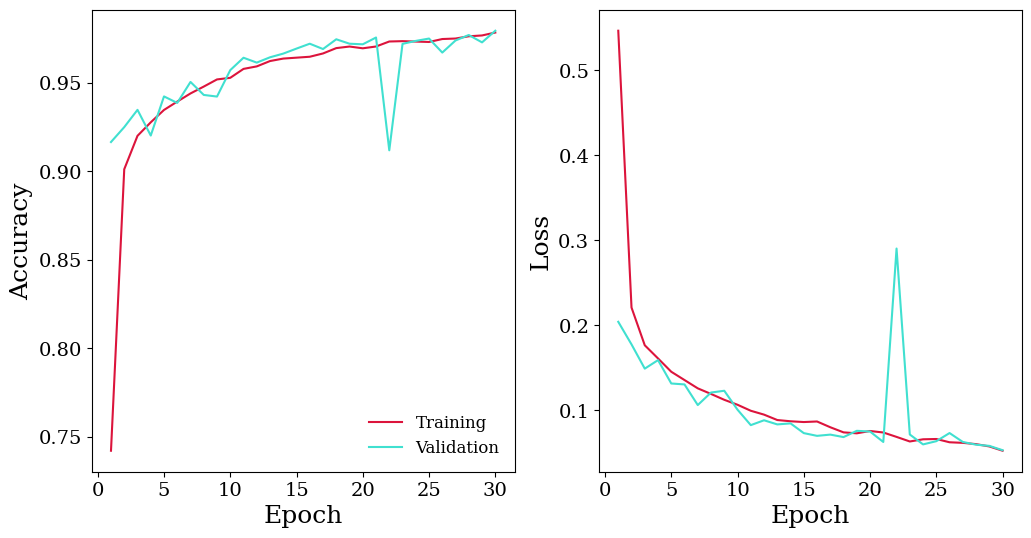

In [400]:
loss_acc(history_ALL, 'ALL')

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy for Gluon: 99.87%
Accuracy for Quark: 99.71%
Accuracy for W: 95.28%
Accuracy for Z: 93.42%
Accuracy for T: 99.92%


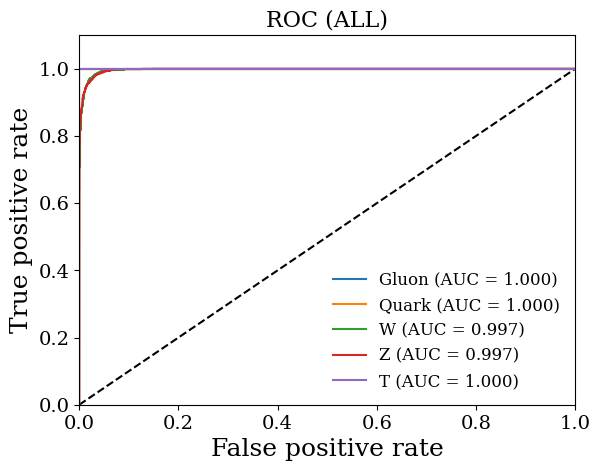

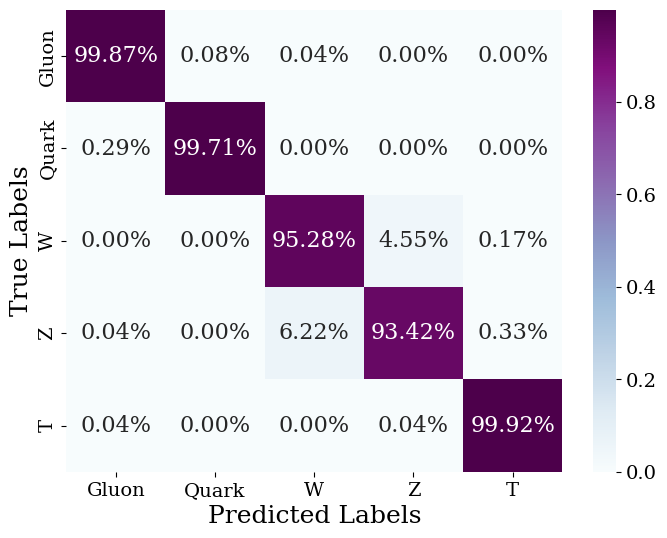

In [ ]:
probabilities_ALL = model_ALL.predict([images_test, hcal_test, ecal_test,pt_test, eta_test, mass_test, 
                mult_test, z_test, 
         split_data['tau3_b1']['test'], split_data['d2_b2']['test'], split_data['d2_a1_b2']['test'], 
         split_data['n2_b2']['test'], split_data['n2_b1']['test'], split_data['tau32_b1']['test'],
         split_data['c1_b1_mmdt']['test'], split_data['c2_b1_mmdt']['test'], split_data['mass_trim']['test'],
         split_data['mass_mmdt']['test'], split_data['mass_sdb2']['test']])

roc_ALL = ROC(probabilities_ALL, 'ALL')

ALL_pred_labels, ALL_acc = confusion_matrix(probabilities_ALL, 'ALL')

## 8. Performance Comparison

This part of the analysis focuses on the overall performance of each model across the full classification task. For this reason several performance metrics are used to evaluate how easily each class can be distinguished from the others: these metrics include the Area Under the ROC Curve (AUC), the F1 score, the maximum accuracy achieved during training, the minimum loss reached during training and the number of trainable parameters.
The models we will be evaluating are:

1. Jet Image CNN
2. Jet Image + Features CNN-MLP
3. Jet Image + ECAL + HCAL Multiview CNN
4. Features-Only MLP
5. Jet Image + ECAL + HCAL + Features Multiview CNN-MLP


In [ ]:
# Extract true class labels (from one-hot encoding if applicable)
y_true = np.argmax(labels_test_binarised, axis=1)

def extract_model_metrics(history, probs, y_true, model_name, model):
    max_train_acc = np.max(history.history['accuracy'])
    final_train_loss = history.history['loss'][-1]
    avg_auc = roc_auc_score(y_true, probs, multi_class='ovr', average='macro')

    pred_labels = np.argmax(probs, axis=1)
    report = classification_report(y_true, pred_labels, output_dict=True)
    avg_f1_macro = report['macro avg']['f1-score']

    return {
        'Model Name': model_name,
        'Max Train Accuracy': round(max_train_acc, 4),
        'Average AUC': round(avg_auc, 4),
        'Average F1 Score': round(avg_f1_macro, 4),
        'Final Train Loss': round(final_train_loss, 4),
        'Number of Parameters': model.count_params()
    }

model_info = [
    ('Jet image', history_images, probabilities_images, model_images),
    ('Features Only', history_features, probabilities_features, model_features),
    ('Jet Image + ECAL + HCAL', history_cal, probabilities_cal, model_cal),
    ('Jet Image + Features', history_images_all_features, probabilities_mad, model_images_all_features),
    ('Jet Image + ECAL + HCAL + Features', history_ALL, probabilities_ALL, model_ALL),
]

results = [
    extract_model_metrics(history, probs, y_true, model_name, model)
    for model_name, history, probs, model in model_info
]

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='Average F1 Score', ascending=False).reset_index(drop=True)

display(df_results)

,Model Name,Max Train Accuracy,Average AUC,Average F1 Score,Final Train Loss,Number of Parameters
0,Jet Image + ECAL + HCAL + Features,0.9783,0.9988,0.9763,0.0526,1136133
1,Jet Image + Features,0.9660,0.9975,0.9610,0.0795,663941
2,Features Only,0.9185,0.9894,0.9071,0.1725,460741
3,Jet Image + ECAL + HCAL,0.9197,0.9880,0.8995,0.2240,401285
4,Jet image,0.7324,0.9225,0.7208,0.7367,270581


Overall, the Jet Image + Features architecture appears to be the most balanced model in this study; its performance is very close to that of the most complex multimodal model, yet it achieves this with far lower architectural complexity and a more practical training cost. This indicates that combining jet images with scalar features already captures most of the discriminative information required for accurate classification and therefore, when computational efficiency is considered alongside predictive quality, this model stands out as the best choice.

Text(0.5, 0, 'Epoch')

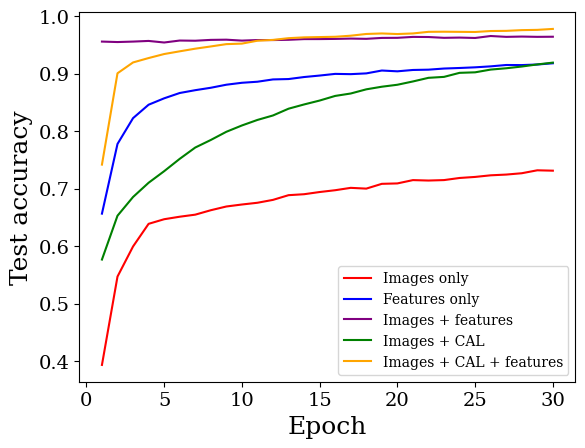

In [ ]:
plt.figure()

plt.plot(np.arange(1, np.size(history_images.history['accuracy']) + 1, 1), history_images.history['accuracy'], 
         label = 'Images only', color='red')
plt.plot(np.arange(1, np.size(history_features.history['accuracy'])+ 1, 1), 
         history_features.history['accuracy'], label = 'Features only', color = 'blue')
plt.plot(np.arange(1, np.size(history_images_all_features.history['accuracy']) + 1, 1), history_images_all_features.history['accuracy'],
        label = 'Images + features', color = 'purple')
plt.plot(np.arange(1, np.size(history_cal.history['accuracy']) + 1, 1), history_cal.history['accuracy'],
        label = 'Images + CAL', color = 'green')
plt.plot(np.arange(1, np.size(history_ALL.history['accuracy']) + 1, 1), history_ALL.history['accuracy'],
        label = 'Images + CAL + features', color = 'orange')

plt.legend(loc='best', fontsize='10')
plt.ylabel('Test accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

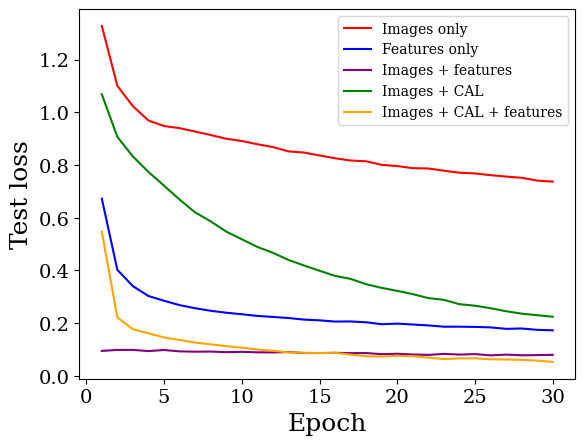

In [ ]:
plt.figure()

plt.plot(np.arange(1, np.size(history_images.history['accuracy']) + 1, 1), history_images.history['loss'], 
         label = 'Images only', color='red')
plt.plot(np.arange(1, np.size(history_features.history['accuracy'])+ 1, 1), 
         history_features.history['loss'], label = 'Features only', color = 'blue')
plt.plot(np.arange(1, np.size(history_images_all_features.history['accuracy']) + 1, 1), history_images_all_features.history['loss'],
        label = 'Images + features', color = 'purple')
plt.plot(np.arange(1, np.size(history_cal.history['accuracy']) + 1, 1), history_cal.history['loss'], 
         label = 'Images + CAL', color='green')
plt.plot(np.arange(1, np.size(history_ALL.history['accuracy'])+ 1, 1), 
         history_ALL.history['loss'], label = 'Images + CAL + features', color = 'orange')

plt.legend(loc='best', fontsize = '10')
plt.ylabel('Test loss')
plt.xlabel('Epoch')


## 9. Which Particle Classes Are Easiest to Distinguish?

To answer this question, we compare the ROC curves on a class-by-class basis rather than model-by-model.  
For each particle type, the True Positive Rate (TPR) is evaluated as a function of the False Positive Rate (FPR), allowing us to assess which classes are more easily separated from the others: classes with ROC curves closer to the top-left corner, and therefore larger AUC values, are considered easier to distinguish.

### 9.1 Gluon

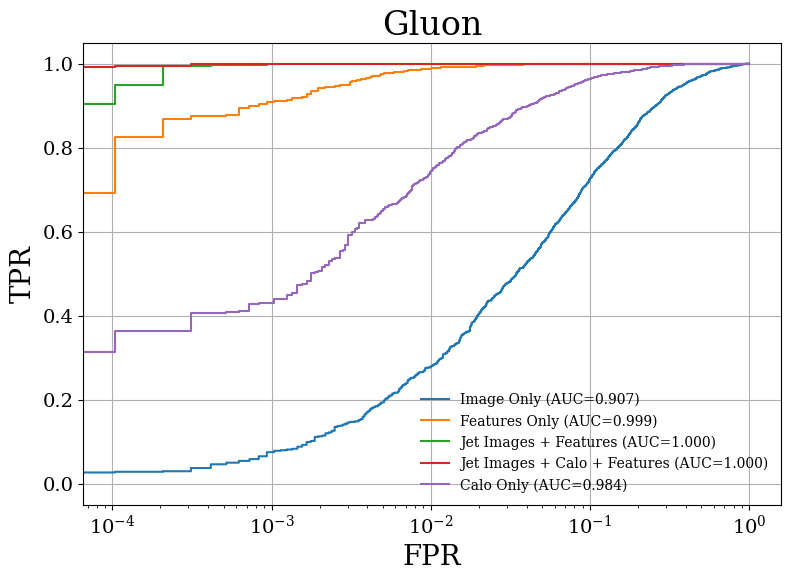

In [405]:
models = [
    ('Image Only', roc_img),
    ('Features Only', roc_features),
    ('Jet Images + Features', roc_img_features),
    ('Jet Images + Calo + Features', roc_ALL),
    ('Calo Only', roc_cal)
]

plt.figure(figsize=(9,6))
plt.xscale('log')

for label, roc_data in models:
    plt.plot(roc_data[0]['FPR'], roc_data[0]['TPR'],
             label=f"{label} (AUC={roc_data[0]['AUC']:.3f})")

plt.legend(loc='lower right', frameon=False, fontsize=10)
plt.xlabel('FPR', fontsize=20)
plt.ylabel('TPR', fontsize=20)
plt.title('Gluon', fontsize=24)
plt.grid(True)
plt.savefig('GluonROC.pdf', dpi=1000, bbox_inches='tight')
plt.show()

### 9.2 Quark

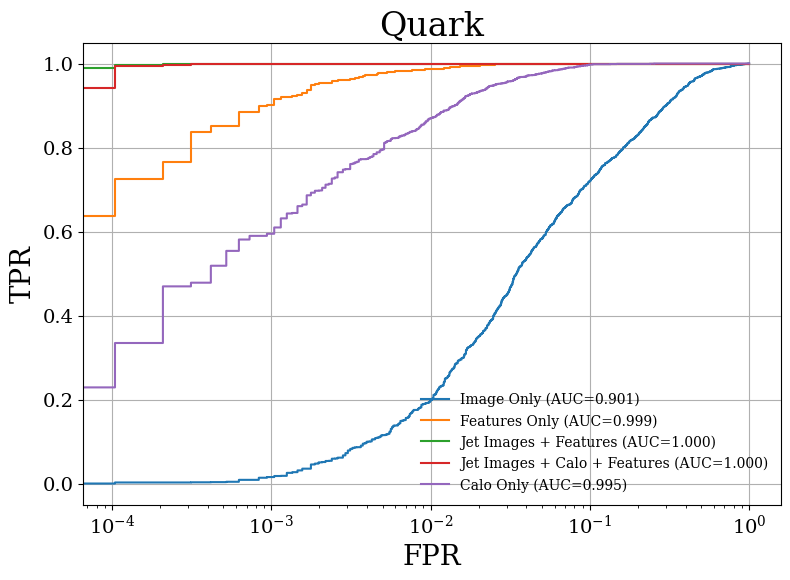

In [406]:
models = [
    ('Image Only', roc_img),
    ('Features Only', roc_features),
    ('Jet Images + Features', roc_img_features),
    ('Jet Images + Calo + Features', roc_ALL),
    ('Calo Only', roc_cal)
]

plt.figure(figsize=(9,6))
plt.xscale('log')

for label, roc_data in models:
    plt.plot(roc_data[1]['FPR'], roc_data[1]['TPR'],
             label=f"{label} (AUC={roc_data[1]['AUC']:.3f})")

plt.legend(loc='lower right', frameon=False, fontsize=10)
plt.xlabel('FPR', fontsize=20)
plt.ylabel('TPR', fontsize=20)
plt.title('Quark', fontsize=24)
plt.grid(True)
plt.savefig('QuarkROC.pdf', dpi=1000, bbox_inches='tight')
plt.show()


### 9.3 W

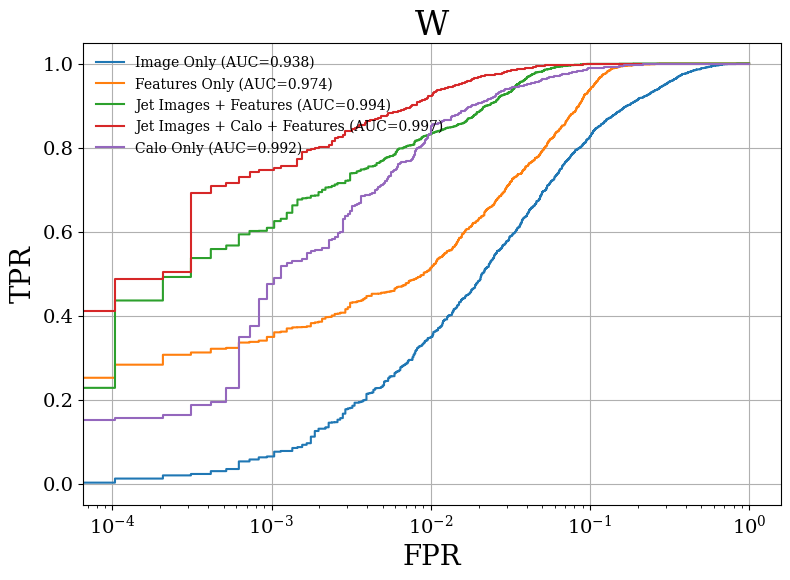

In [407]:
models = [
    ('Image Only', roc_img),
    ('Features Only', roc_features),
    ('Jet Images + Features', roc_img_features),
    ('Jet Images + Calo + Features', roc_ALL),
    ('Calo Only', roc_cal)
]

plt.figure(figsize=(9,6))
plt.xscale('log')

for label, roc_data in models:
    plt.plot(roc_data[2]['FPR'], roc_data[2]['TPR'],
             label=f"{label} (AUC={roc_data[2]['AUC']:.3f})")

plt.legend(loc='upper left', frameon=False, fontsize=10)
plt.xlabel('FPR', fontsize=20)
plt.ylabel('TPR', fontsize=20)
plt.title('W', fontsize=24)
plt.grid(True)
plt.savefig('WROC.pdf', dpi=1000, bbox_inches='tight')
plt.show()

### 9.4 Z

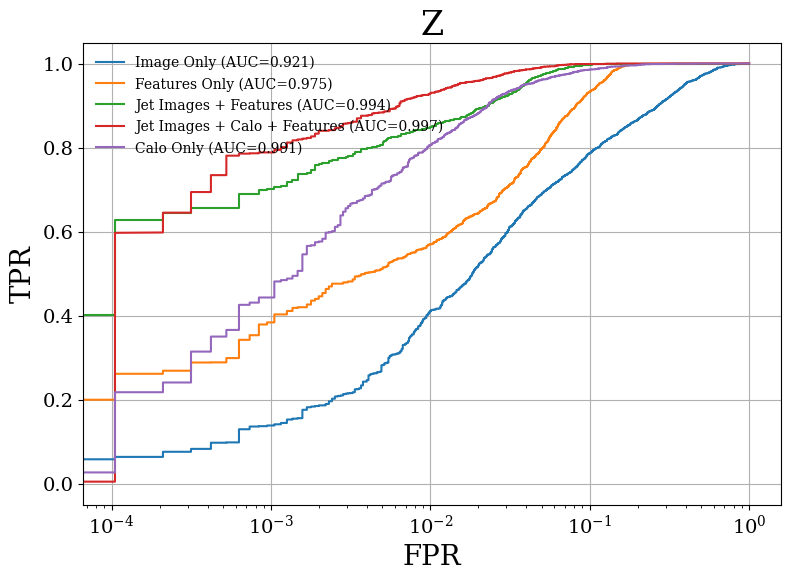

In [408]:
models = [
    ('Image Only', roc_img),
    ('Features Only', roc_features),
    ('Jet Images + Features', roc_img_features),
    ('Jet Images + Calo + Features', roc_ALL),
    ('Calo Only', roc_cal)
]

plt.figure(figsize=(9,6))
plt.xscale('log')

for label, roc_data in models:
    plt.plot(roc_data[3]['FPR'], roc_data[3]['TPR'],
             label=f"{label} (AUC={roc_data[3]['AUC']:.3f})")

plt.legend(loc='upper left', frameon=False, fontsize=10)
plt.xlabel('FPR', fontsize=20)
plt.ylabel('TPR', fontsize=20)
plt.title('Z', fontsize=24)
plt.grid(True)
plt.savefig('ZROC.pdf', dpi=1000, bbox_inches='tight')
plt.show()

### 9.5 Top

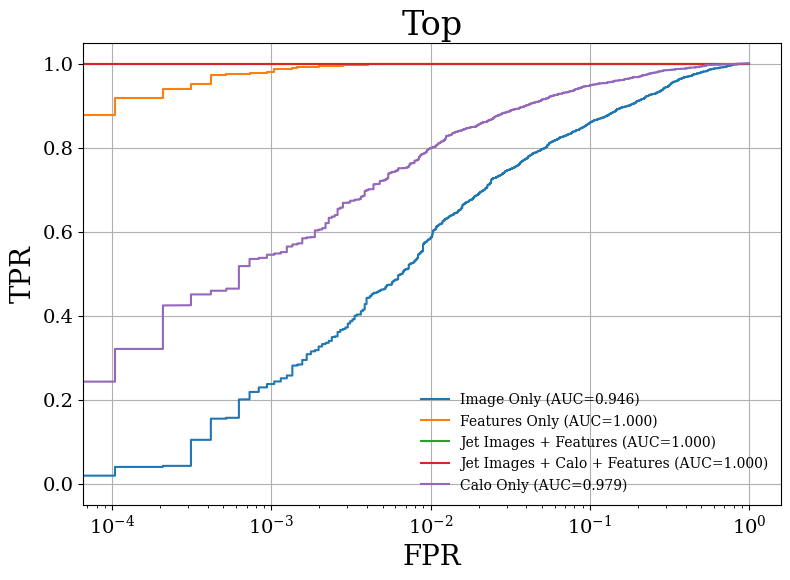

In [409]:
models = [
    ('Image Only', roc_img),
    ('Features Only', roc_features),
    ('Jet Images + Features', roc_img_features),
    ('Jet Images + Calo + Features', roc_ALL),
    ('Calo Only', roc_cal)
]

plt.figure(figsize=(9,6))
plt.xscale('log')

for label, roc_data in models:
    plt.plot(roc_data[4]['FPR'], roc_data[4]['TPR'],
             label=f"{label} (AUC={roc_data[4]['AUC']:.3f})")

plt.legend(loc='lower right', frameon=False, fontsize=10)
plt.xlabel('FPR', fontsize=20)
plt.ylabel('TPR', fontsize=20)
plt.title('Top', fontsize=24)
plt.grid(True)
plt.savefig('TopROC.pdf', dpi=1000, bbox_inches='tight')
plt.show()

## 10. Conclusion

Five architectures were systematically evaluated for LHC jet classification, using various image and
feature combinations, and achieving consistently strong performance for multi-input models (accu-
racy > 90%). The most accurate configuration, combining jet/ECAL/HCAL images with 16 HLFs,
delivered 97.8% accuracy and 0.976 F1 score, though at highest computational cost. On the other
hand, the model combining jet images with 16 HLFs offered similar performance (96.6% accuracy)
with substantially faster training (24 s/epoch), representing the optimal accuracy-efficiency tradeoff
for practical deployment. The class-wise analysis also showed that the usefulness of additional in-
puts depends on the particle category, confirming that physically meaningful scalar features provide
complementary information rather than a uniform improvement across all classes. Taken together,
these results support the use of multimodal deep learning as a robust and flexible approach for jet
classification in high-energy physics.  Even though challenges persist (e.g. model scalability and potential overfitting from redundant features), precise jet tagging is crucial for LHC precision measurements and searches beyond the Standard
Model.